# Presentasi Proyek
## Perbandingan Fuzzy Mamdani dan Sugeno dalam Penilaian Performa Karyawan Berbasis HR Analytics

Notebook ini menggabungkan tahapan **Preprocessing**, **Implementasi Fuzzy Mamdani**, dan **Implementasi Fuzzy Sugeno** dalam satu alur presentasi.

---
## 1. Import Library & Load Data

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CSV_FILE = "Employee_Performance_Dataset.csv"
data = pd.read_csv(CSV_FILE)

print(f"Shape dataset asli : {data.shape}")
print(f"Kolom               : {list(data.columns)}")
data.head()

Shape dataset asli : (5000, 13)
Kolom               : ['Employee ID', 'Name', 'Department', 'Job Role', 'Performance Score', 'KPI Score', 'Attendance (%)', 'Peer Rating', 'Task Completion (%)', 'Work Hours Logged', 'Manager Feedback', 'Training Hours', 'Promotion Eligibility']


,Employee ID,Name,Department,Job Role,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Manager Feedback,Training Hours,Promotion Eligibility
0,376063,Manikya Badami,Sales,Sales Executive,61,91.03,94.40,4.5,78.19,42,3.7,18,No
1,810690,Zara Mahal,Marketing,Marketing Executive,91,83.36,78.45,4.7,71.39,46,4.5,15,Yes
2,520956,Sana Gera,Finance,Accountant,100,65.39,99.50,4.4,80.20,51,3.5,7,No
3,202996,Zoya Wadhwa,Marketing,Content Strategist,100,82.90,79.83,4.3,71.51,43,5.0,9,Yes
4,383410,Baiju Doctor,Sales,Sales Executive,80,90.90,89.92,3.7,78.03,51,3.1,29,No


---
## 2. Seleksi Variabel

Dari 13 kolom yang tersedia, dipilih **6 variabel input** dan **1 variabel output** yang relevan untuk sistem fuzzy penilaian performa karyawan:

| Peran | Variabel | Alasan Pemilihan |
|---|---|---|
| Input | KPI Score | Mengukur produktivitas dan pencapaian target |
| Input | Attendance (%) | Mencerminkan kedisiplinan dan kehadiran |
| Input | Peer Rating | Evaluasi rekan kerja terhadap kolaborasi |
| Input | Task Completion (%) | Tingkat penyelesaian tugas yang diberikan |
| Input | Manager Feedback | Evaluasi langsung dari atasan |
| Input | Training Hours | Intensitas pengembangan kemampuan |
| Output | Performance Score | Nilai performa aktual sebagai acuan evaluasi |

Kolom lain (`Employee ID`, `Name`, `Department`, `Job Role`, `Work Hours Logged`, `Promotion Eligibility`) tidak digunakan karena bersifat identitas atau di luar cakupan input fuzzy.

In [65]:
INPUT_COLS  = ['KPI Score', 'Attendance (%)', 'Peer Rating',
               'Task Completion (%)', 'Manager Feedback', 'Training Hours']
OUTPUT_COL  = 'Performance Score'
SELECTED    = INPUT_COLS + [OUTPUT_COL]

df = data[SELECTED].copy()
print(f"Shape setelah seleksi variabel : {df.shape}")
df.head()

Shape setelah seleksi variabel : (5000, 7)


,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Manager Feedback,Training Hours,Performance Score
0,91.03,94.40,4.5,78.19,3.7,18,61
1,83.36,78.45,4.7,71.39,4.5,15,91
2,65.39,99.50,4.4,80.20,3.5,7,100
3,82.90,79.83,4.3,71.51,5.0,9,100
4,90.90,89.92,3.7,78.03,3.1,29,80


---
## 3. Penanganan Missing Values

Pemeriksaan nilai kosong (null/NaN) dilakukan pada seluruh kolom terpilih. Jika ditemukan, baris tersebut akan dihapus (`dropna`) karena jumlahnya biasanya kecil dan tidak merusak representasi data.

In [66]:
print("=== Jumlah Missing Values per Kolom ===")
print(df.isnull().sum())
print(f"\nTotal missing values : {df.isnull().sum().sum()}")

rows_before = len(df)
df = df.dropna()
rows_after  = len(df)
print(f"\nBaris sebelum dropna : {rows_before}")
print(f"Baris setelah dropna : {rows_after}")
print(f"Baris dihapus        : {rows_before - rows_after}")

=== Jumlah Missing Values per Kolom ===
KPI Score              0
Attendance (%)         0
Peer Rating            0
Task Completion (%)    0
Manager Feedback       0
Training Hours         0
Performance Score      0
dtype: int64

Total missing values : 0

Baris sebelum dropna : 5000
Baris setelah dropna : 5000
Baris dihapus        : 0


---
## 4. Statistik Deskriptif

Statistik deskriptif (min, max, mean, median, standar deviasi, kuartil) dihitung untuk setiap variabel. Nilai-nilai ini menjadi **acuan utama dalam menentukan batas membership function** pada sistem fuzzy.

In [67]:
print(f"{'Variabel':<22} {'Min':>8} {'Q1':>8} {'Median':>8} {'Mean':>8} {'Q3':>8} {'Max':>8} {'Std':>8}")
print("-" * 80)
for col in SELECTED:
    mn  = df[col].min()
    q1  = df[col].quantile(0.25)
    med = df[col].median()
    avg = df[col].mean()
    q3  = df[col].quantile(0.75)
    mx  = df[col].max()
    std = df[col].std()
    print(f"{col:<22} {mn:>8.2f} {q1:>8.2f} {med:>8.2f} {avg:>8.2f} {q3:>8.2f} {mx:>8.2f} {std:>8.2f}")

Variabel                    Min       Q1   Median     Mean       Q3      Max      Std
--------------------------------------------------------------------------------
KPI Score                 60.01    68.33    77.34    77.38    86.05    94.99    10.16
Attendance (%)            75.01    81.13    87.41    87.47    93.75   100.00     7.23
Peer Rating                3.00     3.50     4.00     4.00     4.50     5.00     0.58
Task Completion (%)       70.01    77.32    85.12    84.98    92.47   100.00     8.70
Manager Feedback           3.00     3.50     4.00     4.00     4.50     5.00     0.58
Training Hours             0.00     7.00    15.00    14.88    23.00    30.00     9.01
Performance Score         50.00    62.00    75.00    74.78    87.00   100.00    14.67


---
## 5. Pemeriksaan Outlier (Metode IQR)

Outlier dideteksi menggunakan metode **IQR (Interquartile Range)**. Suatu nilai dikategorikan outlier apabila:

$$\text{nilai} < Q1 - 1.5 \times IQR \quad \text{atau} \quad \text{nilai} > Q3 + 1.5 \times IQR$$

Selain pengecekan numerik, boxplot divisualisasikan untuk melihat sebaran dan keberadaan outlier secara visual.

In [68]:
print("=== Deteksi Outlier (Metode IQR) ===")
print(f"{'Variabel':<22} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Batas Bawah':>12} {'Batas Atas':>12} {'Outlier':>8}")
print("-" * 85)
for col in SELECTED:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n_out = ((df[col] < lb) | (df[col] > ub)).sum()
    print(f"{col:<22} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {lb:>12.2f} {ub:>12.2f} {n_out:>8}")

=== Deteksi Outlier (Metode IQR) ===
Variabel                     Q1       Q3      IQR  Batas Bawah   Batas Atas  Outlier
-------------------------------------------------------------------------------------
KPI Score                 68.33    86.05    17.72        41.74       112.63        0
Attendance (%)            81.13    93.75    12.62        62.20       112.69        0
Peer Rating                3.50     4.50     1.00         2.00         6.00        0
Task Completion (%)       77.32    92.47    15.16        54.58       115.20        0
Manager Feedback           3.50     4.50     1.00         2.00         6.00        0
Training Hours             7.00    23.00    16.00       -17.00        47.00        0
Performance Score         62.00    87.00    25.00        24.50       124.50        0


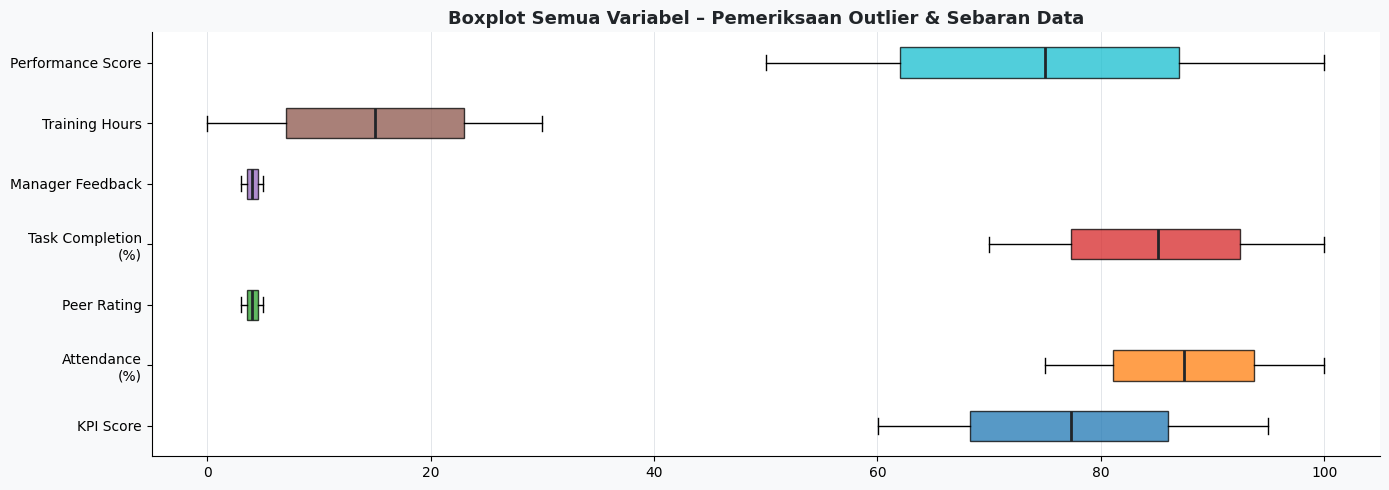

In [69]:
fig, ax = plt.subplots(figsize=(14, 5), facecolor='#F8F9FA')
ax.set_facecolor('white')

COLORS = ['#1F77B4','#FF7F0E','#2CA02C','#D62728','#9467BD','#8C564B','#17BECF']
bplot  = ax.boxplot(
    [df[c] for c in SELECTED],
    vert=False, patch_artist=True,
    tick_labels=[c.replace(' (%)', '\n(%)') for c in SELECTED],
    medianprops=dict(color='#212529', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5)
)
for patch, clr in zip(bplot['boxes'], COLORS):
    patch.set_facecolor(clr)
    patch.set_alpha(0.75)

ax.set_title('Boxplot Semua Variabel – Pemeriksaan Outlier & Sebaran Data',
             fontsize=13, fontweight='bold', color='#212529')
ax.grid(True, axis='x', color='#DEE2E6', linewidth=0.6)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 6. Visualisasi Distribusi Data (Histogram)

Distribusi setiap variabel divisualisasikan menggunakan histogram. Garis vertikal **mean** (putus-putus hitam) dan **median** (titik-titik merah) ditambahkan untuk membantu memahami bentuk distribusi dan posisi pusat data — informasi ini digunakan sebagai dasar penentuan batas membership function.

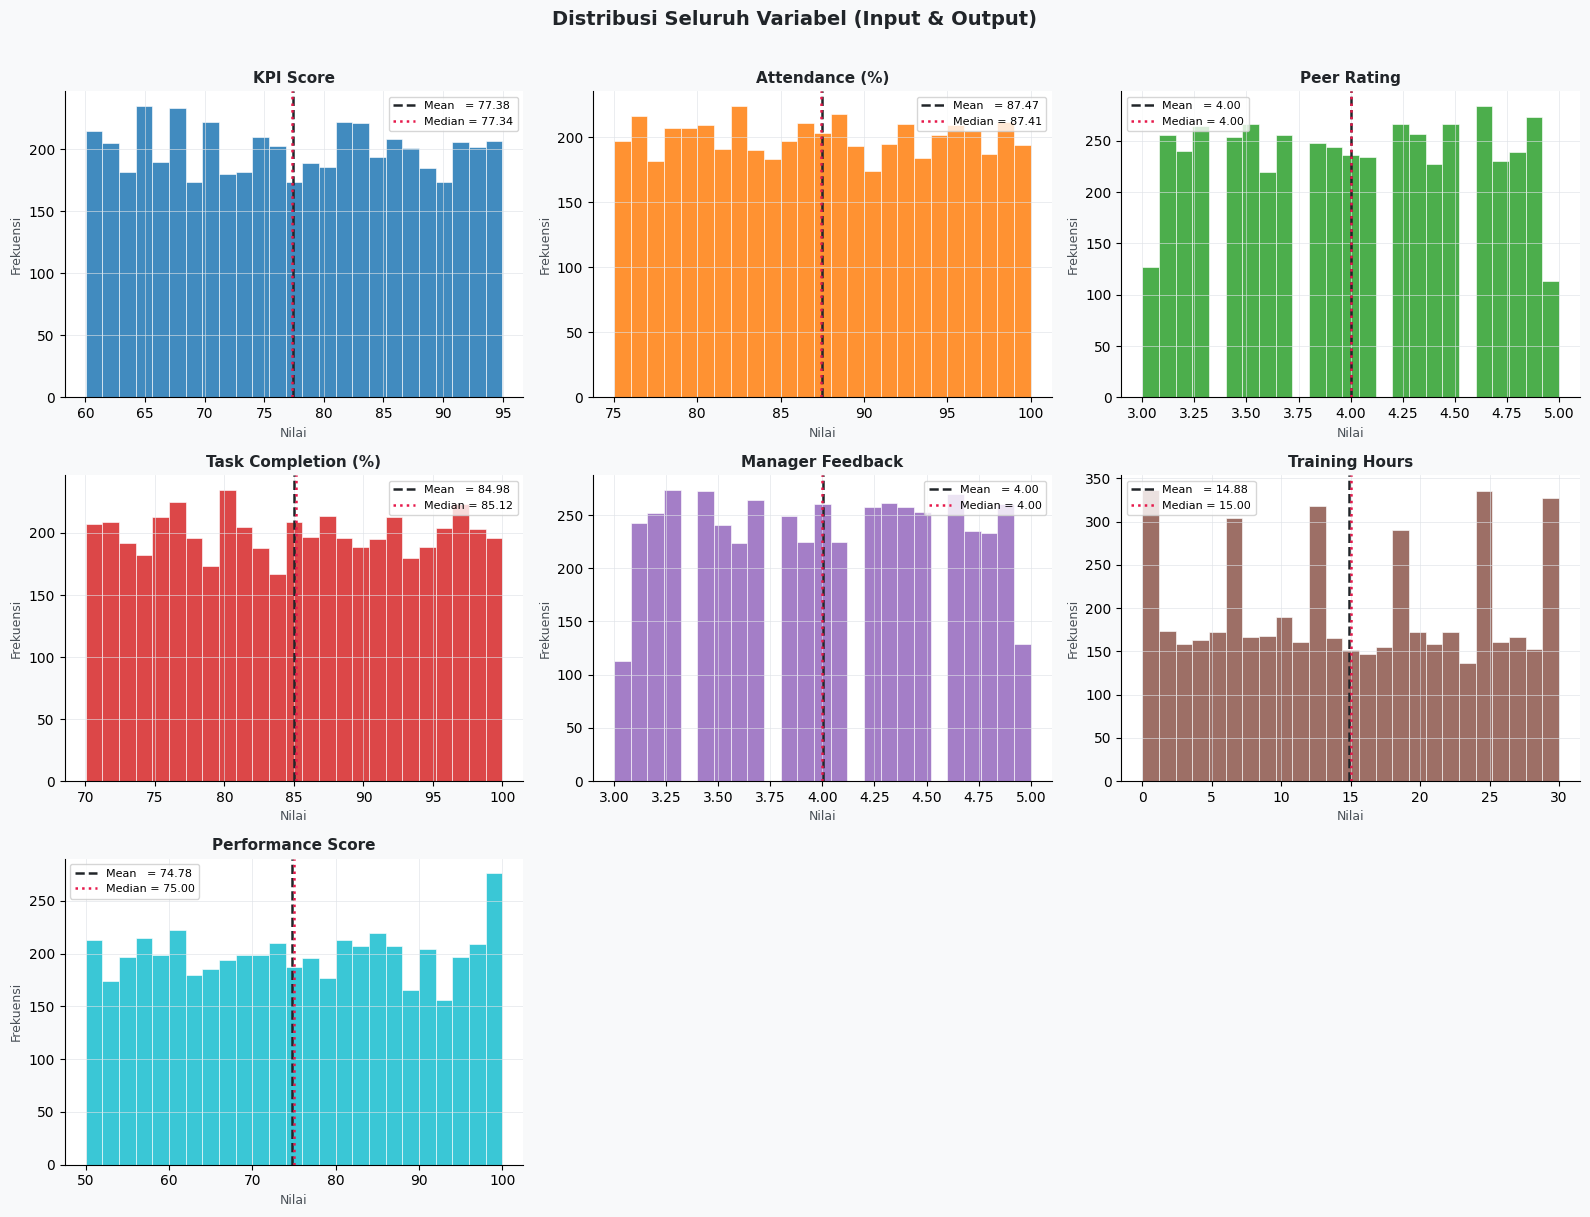

In [70]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), facecolor='#F8F9FA')
axes = axes.flatten()
COLORS = ['#1F77B4','#FF7F0E','#2CA02C','#D62728','#9467BD','#8C564B','#17BECF']

for i, (col, clr) in enumerate(zip(SELECTED, COLORS)):
    ax = axes[i]
    ax.set_facecolor('white')
    ax.hist(df[col], bins=25, color=clr, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(df[col].mean(),   color='#212529', lw=1.8, ls='--',
               label=f"Mean   = {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color='#E6194B', lw=1.8, ls=':',
               label=f"Median = {df[col].median():.2f}")
    ax.set_title(col, fontsize=11, fontweight='bold', color='#212529')
    ax.set_xlabel('Nilai', fontsize=9, color='#495057')
    ax.set_ylabel('Frekuensi', fontsize=9, color='#495057')
    ax.legend(fontsize=8)
    ax.grid(True, color='#DEE2E6', linewidth=0.6, alpha=0.7)
    ax.spines[['top','right']].set_visible(False)

# sembunyikan subplot kosong
for j in range(len(SELECTED), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribusi Seluruh Variabel (Input & Output)',
             fontsize=14, fontweight='bold', color='#212529', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Analisis Korelasi

Korelasi Pearson dihitung antara semua variabel. Fokus utamanya adalah korelasi setiap **input terhadap output** (`Performance Score`) untuk memvalidasi pemilihan variabel.

> **Catatan:** Nilai korelasi yang mendekati nol **bukan berarti variabel tidak relevan**. Korelasi Pearson hanya mengukur hubungan **linear**. Nilai mendekati nol justru mengindikasikan bahwa hubungan antar variabel bersifat **non-linear dan kompleks** — ini menjadi justifikasi ilmiah mengapa pendekatan **sistem fuzzy lebih tepat** dibanding model regresi linear.

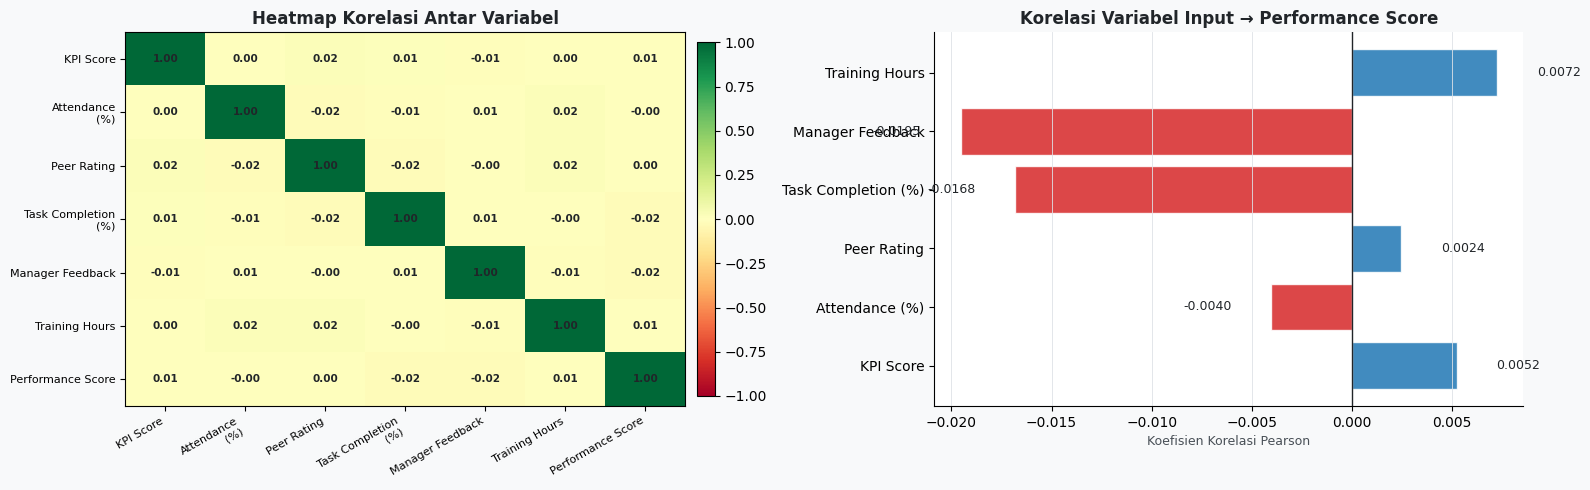


=== Matriks Korelasi (Tabel) ===


,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Manager Feedback,Training Hours,Performance Score
KPI Score,1.0000,0.0025,0.0165,0.0094,-0.0103,0.0026,0.0052
Attendance (%),0.0025,1.0000,-0.0194,-0.0109,0.0053,0.0164,-0.0040
Peer Rating,0.0165,-0.0194,1.0000,-0.0215,-0.0033,0.0170,0.0024
Task Completion (%),0.0094,-0.0109,-0.0215,1.0000,0.0068,-0.0048,-0.0168
Manager Feedback,-0.0103,0.0053,-0.0033,0.0068,1.0000,-0.0107,-0.0195
Training Hours,0.0026,0.0164,0.0170,-0.0048,-0.0107,1.0000,0.0072
Performance Score,0.0052,-0.0040,0.0024,-0.0168,-0.0195,0.0072,1.0000


In [71]:
corr = df[SELECTED].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#F8F9FA')

# --- Heatmap korelasi ---
ax1 = axes[0]
ax1.set_facecolor('white')
im = ax1.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
labels = [c.replace(' (%)', '\n(%)') for c in SELECTED]
ax1.set_xticks(range(len(SELECTED))); ax1.set_xticklabels(labels, fontsize=8, rotation=30, ha='right')
ax1.set_yticks(range(len(SELECTED))); ax1.set_yticklabels(labels, fontsize=8)
for i in range(len(SELECTED)):
    for j in range(len(SELECTED)):
        ax1.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                 fontsize=7.5, fontweight='bold', color='#212529')
plt.colorbar(im, ax=ax1, fraction=0.03, pad=0.02)
ax1.set_title('Heatmap Korelasi Antar Variabel', fontsize=12, fontweight='bold', color='#212529')

# --- Bar korelasi input vs output ---
ax2 = axes[1]
ax2.set_facecolor('white')
corr_out    = corr[OUTPUT_COL].drop(OUTPUT_COL)
bar_colors  = ['#1F77B4' if v >= 0 else '#D62728' for v in corr_out.values]
bars = ax2.barh(corr_out.index, corr_out.values, color=bar_colors, edgecolor='white', alpha=0.85)
ax2.axvline(0, color='#212529', lw=1)
for bar, val in zip(bars, corr_out.values):
    offset = 0.002 if val >= 0 else -0.002
    ha     = 'left'  if val >= 0 else 'right'
    ax2.text(val + offset, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha=ha, fontsize=9, color='#212529')
ax2.set_title(f'Korelasi Variabel Input → {OUTPUT_COL}', fontsize=12, fontweight='bold', color='#212529')
ax2.set_xlabel('Koefisien Korelasi Pearson', fontsize=9, color='#495057')
ax2.grid(True, axis='x', color='#DEE2E6', linewidth=0.6)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== Matriks Korelasi (Tabel) ===")
corr.round(4)

---
## 8. Penentuan Batas Membership Function

Batas membership function ditentukan menggunakan pendekatan **Percentile-based (Q1, Median, Q3)** yang dikombinasikan dengan nilai ekstrem (Min, Max) dari data aktual. Pendekatan ini dipilih karena:
- Bersumber dari distribusi data nyata, bukan asumsi subjektif
- Setiap himpunan fuzzy mencakup porsi data yang proporsional
- Dapat dipertanggungjawabkan secara ilmiah di laporan

Setiap variabel dibagi menjadi **3 himpunan linguistik** dengan fungsi keanggotaan **triangular** dan **trapezoidal**:
- **Rendah / Buruk / Sedikit** : dari Min hingga sekitar Median, puncak di Q1
- **Sedang / Cukup**           : dari Q1 hingga Q3, puncak di Median
- **Tinggi / Baik / Banyak**  : dari sekitar Median hingga Max, puncak di Q3

In [72]:
# Batas membership function berdasarkan Min, Q1, Median, Q3, Max
# Format per himpunan: [a, b, c] triangular  atau  [a, b, c, d] trapezoidal
# Triangular  : naik dari a ke b (puncak), turun dari b ke c
# Trapezoidal : naik dari a ke b, plateau b–c, turun dari c ke d

MEMBERSHIP = {
    'KPI Score': {
        # Range: [60.01, 94.99]  Q1=68.33  Median=77.34  Q3=86.05
        'Sangat_Rendah' : [60, 60, 66.80, 68.33], #trapezoidal – bahu kiri
        'Rendah' : [66.80, 68.33, 77.34],   # triangular
        'Sedang' : [68.33, 77.34, 86.05],   # triangular
        'Tinggi' : [77.34, 86.05, 87.81],   # triangular
        'Sangat_Tinggi' : [86.05, 87.81, 95.00, 95.00],   # trapezoidal – bahu kanan
    },
    'Attendance (%)': {
        # Range: [75.01, 100.00]  Q1=81.13  Median=87.41  Q3=93.75
        'Sangat_Rendah' : [75, 75, 79.95, 81.13],
        'Rendah' : [79.95, 81.13, 87.41],
        'Sedang' : [81.13, 87.41, 93.75],
        'Tinggi' : [87.41, 93.75, 95.04],
        'Sangat_Tinggi' : [93.75, 95.04, 100, 100],
    },
    'Peer Rating': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Task Completion (%)': {
        # Range: [70.01, 100.00]  Q1=77.32  Median=85.12  Q3=92.47
        'Sangat_Rendah' : [70, 70, 75.99, 77.32],
        'Rendah' : [75.99, 77.32, 85.12],
        'Sedang' : [77.32, 85.12, 92.47],
        'Tinggi' : [85.12, 92.47, 94.05],
        'Sangat_Tinggi' : [92.47, 94.05, 100, 100],
    },
    'Manager Feedback': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Training Hours': {
        # Range: [0, 30]  Q1=7.00  Median=15.00  Q3=23.00
        'Sangat_Sedikit' : [0, 0, 5, 7],
        'Sedikit' : [5, 7, 15],
        'Cukup' : [7, 15, 23],
        'Banyak' : [15, 23, 24],
        'Sangat_Banyak' : [23, 24, 30, 30],
    },
}

print("=== Ringkasan Batas Membership Function ===")
print(f"{'Variabel':<22} {'Himpunan':<10} {'Tipe':<14} {'Parameter'}")
print("-" * 70)
for var, himpunan in MEMBERSHIP.items():
    for nama, params in himpunan.items():
        tipe = 'Trapezoidal' if len(params) == 4 else 'Triangular'
        print(f"{var:<22} {nama:<10} {tipe:<14} {params}")
    print()

=== Ringkasan Batas Membership Function ===
Variabel               Himpunan   Tipe           Parameter
----------------------------------------------------------------------
KPI Score              Sangat_Rendah Trapezoidal    [60, 60, 66.8, 68.33]
KPI Score              Rendah     Triangular     [66.8, 68.33, 77.34]
KPI Score              Sedang     Triangular     [68.33, 77.34, 86.05]
KPI Score              Tinggi     Triangular     [77.34, 86.05, 87.81]
KPI Score              Sangat_Tinggi Trapezoidal    [86.05, 87.81, 95.0, 95.0]

Attendance (%)         Sangat_Rendah Trapezoidal    [75, 75, 79.95, 81.13]
Attendance (%)         Rendah     Triangular     [79.95, 81.13, 87.41]
Attendance (%)         Sedang     Triangular     [81.13, 87.41, 93.75]
Attendance (%)         Tinggi     Triangular     [87.41, 93.75, 95.04]
Attendance (%)         Sangat_Tinggi Trapezoidal    [93.75, 95.04, 100, 100]

Peer Rating            Buruk      Trapezoidal    [3.0, 3.0, 3.5, 4.0]
Peer Rating            C

### Visualisasi Membership Function

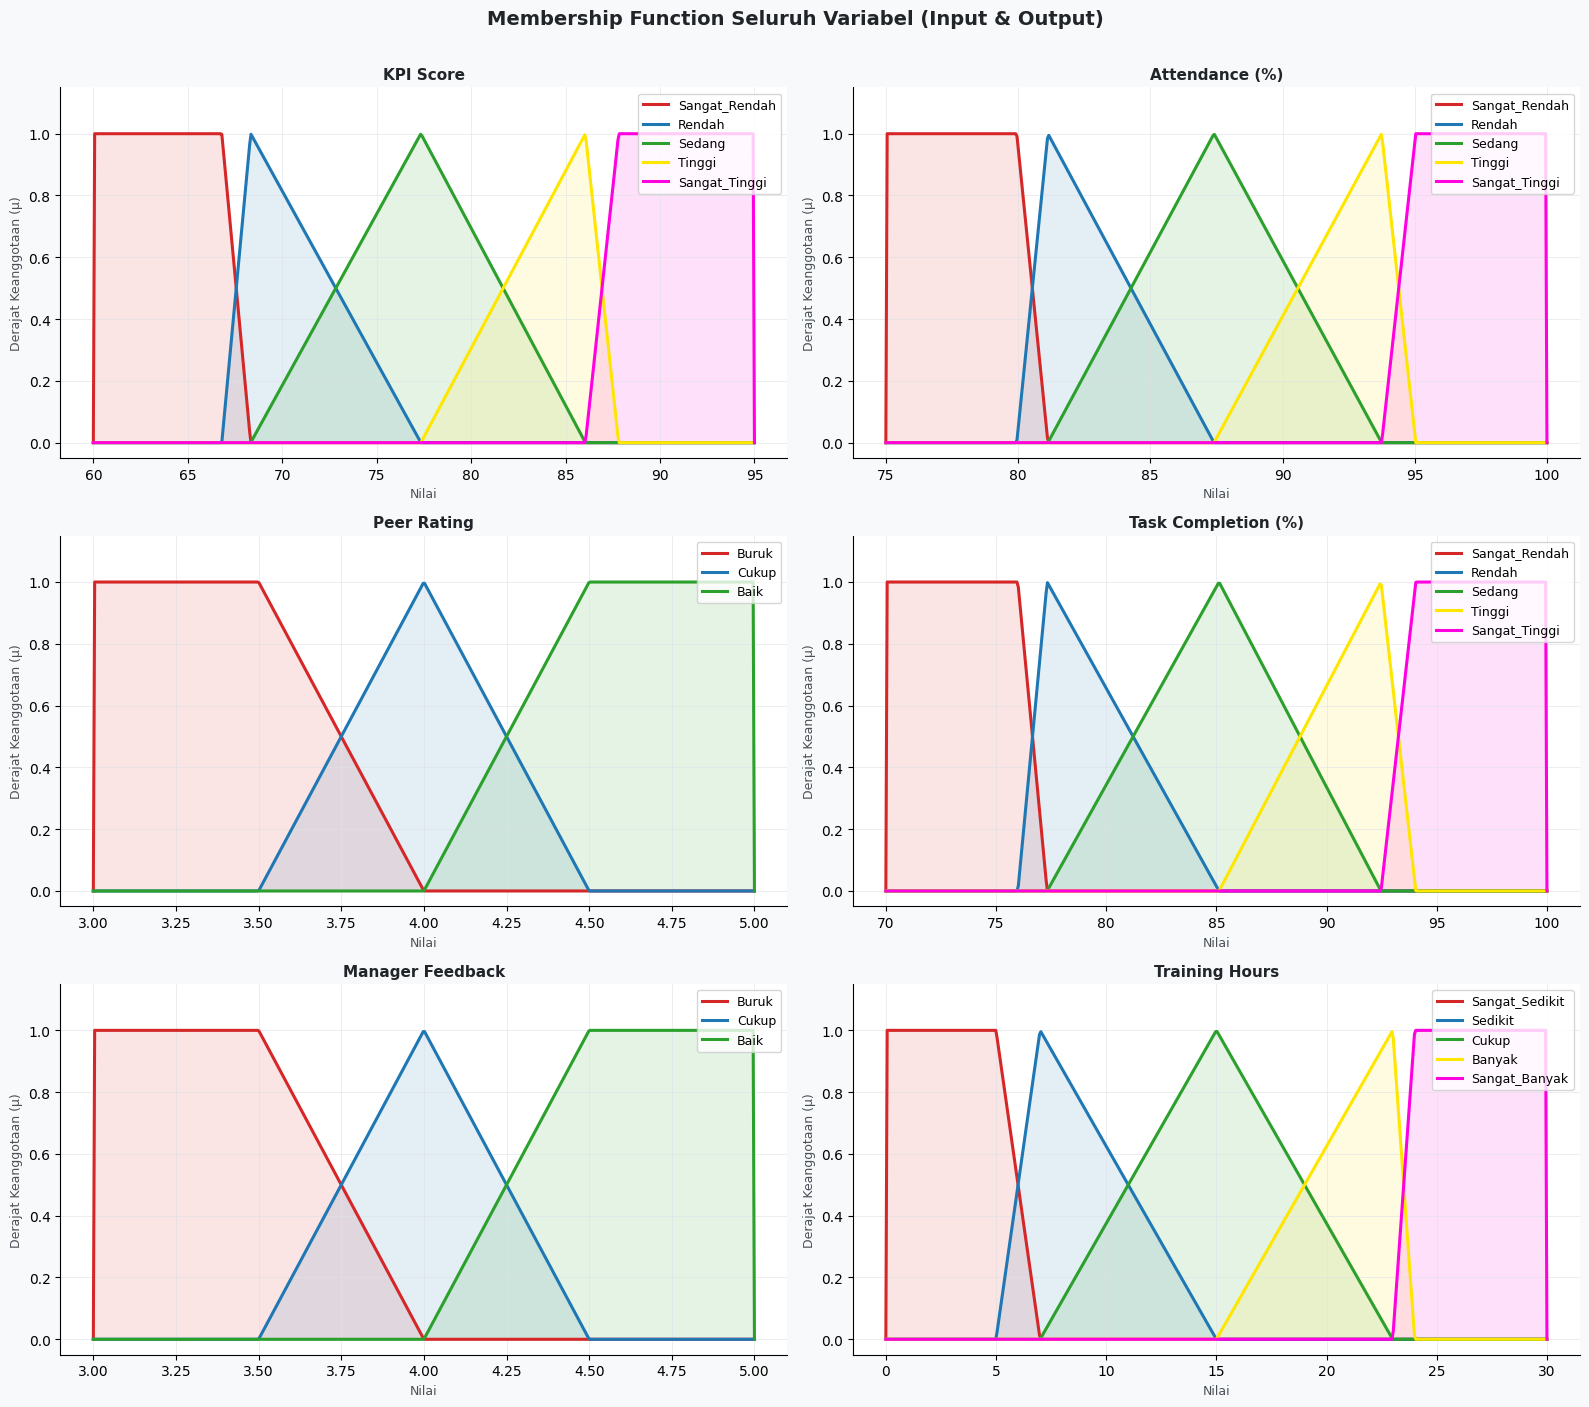

In [73]:
def trimf(x, params):
    """Triangular membership function [a, b, c]"""
    a, b, c = params
    return np.maximum(0, np.minimum((x-a)/(b-a+1e-10), (c-x)/(c-b+1e-10)))

def trapmf(x, params):
    """Trapezoidal membership function [a, b, c, d]"""
    a, b, c, d = params
    return np.maximum(0, np.minimum(
        np.minimum((x-a)/(b-a+1e-10), 1),
        (d-x)/(d-c+1e-10)
    ))

COLORS_MF = ['#D62728', '#1F77B4', '#2CA02C', "#FFE600", "#FF00E1"]
fig, axes = plt.subplots(4, 2, figsize=(16, 18), facecolor='#F8F9FA')
axes = axes.flatten()

for idx, (var, himpunan) in enumerate(MEMBERSHIP.items()):
    ax  = axes[idx]
    ax.set_facecolor('white')
    all_params = [p for p in himpunan.values()]
    x_min = min(p[0] for p in all_params)
    x_max = max(p[-1] for p in all_params)
    x = np.linspace(x_min, x_max, 500)

    for (nama, params), clr in zip(himpunan.items(), COLORS_MF):
        if len(params) == 3:
            y = trimf(x, params)
        else:
            y = trapmf(x, params)
        ax.plot(x, y, color=clr, lw=2.2, label=nama)
        ax.fill_between(x, y, alpha=0.12, color=clr)

    ax.set_title(var, fontsize=11, fontweight='bold', color='#212529')
    ax.set_xlabel('Nilai', fontsize=9, color='#495057')
    ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=9, color='#495057')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, color='#DEE2E6', linewidth=0.6, alpha=0.7)
    ax.spines[['top','right']].set_visible(False)

# sembunyikan subplot kosong
for j in range(len(MEMBERSHIP), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Membership Function Seluruh Variabel (Input & Output)',
             fontsize=14, fontweight='bold', color='#212529', y=1.005)
plt.tight_layout()
plt.show()

---
## 9. Ringkasan Preprocessing

Seluruh tahapan preprocessing telah selesai. Berikut ringkasan hasil yang siap digunakan untuk implementasi Fuzzy Mamdani dan Fuzzy Sugeno:

In [74]:
print("======================================================")
print("         RINGKASAN HASIL PREPROCESSING                ")
print("======================================================")
print(f"  Total data bersih       : {len(df):,} baris")
print(f"  Variabel input          : {len(INPUT_COLS)} kolom")
print(f"  Variabel output         : {OUTPUT_COL}")
print(f"  Missing values          : 0 (tidak ada)")
print(f"  Outlier                 : 0 (tidak ada)")
print(f"  Metode MF               : Triangular & Trapezoidal")
print(f"  Jumlah himpunan per var : 3 (Rendah/Buruk/Sedikit,")
print(f"                            Sedang/Cukup, Tinggi/Baik/Banyak)")
print("------------------------------------------------------")
print("  Variabel & Universe of Discourse:")
for col in SELECTED:
    tag = "[OUTPUT]" if col == OUTPUT_COL else "[INPUT] "
    print(f"  {tag}  {col:<22}: [{df[col].min():.2f}, {df[col].max():.2f}]")
print("======================================================")
print("  Dataset siap digunakan untuk implementasi:")
print("    - Fuzzy Mamdani")
print("    - Fuzzy Sugeno")
print("  Gunakan dictionary MEMBERSHIP untuk batas MF.")
print("======================================================")

         RINGKASAN HASIL PREPROCESSING                
  Total data bersih       : 5,000 baris
  Variabel input          : 6 kolom
  Variabel output         : Performance Score
  Missing values          : 0 (tidak ada)
  Outlier                 : 0 (tidak ada)
  Metode MF               : Triangular & Trapezoidal
  Jumlah himpunan per var : 3 (Rendah/Buruk/Sedikit,
                            Sedang/Cukup, Tinggi/Baik/Banyak)
------------------------------------------------------
  Variabel & Universe of Discourse:
  [INPUT]   KPI Score             : [60.01, 94.99]
  [INPUT]   Attendance (%)        : [75.01, 100.00]
  [INPUT]   Peer Rating           : [3.00, 5.00]
  [INPUT]   Task Completion (%)   : [70.01, 100.00]
  [INPUT]   Manager Feedback      : [3.00, 5.00]
  [INPUT]   Training Hours        : [0.00, 30.00]
  [OUTPUT]  Performance Score     : [50.00, 100.00]
  Dataset siap digunakan untuk implementasi:
    - Fuzzy Mamdani
    - Fuzzy Sugeno
  Gunakan dictionary MEMBERSHIP untuk bat

---
# Implementasi Fuzzy Mamdani
Dataset yang digunakan merupakan hasil preprocessing pada bagian sebelumnya.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

INPUT_COLS = ['KPI Score', 'Attendance (%)', 'Peer Rating',
              'Task Completion (%)', 'Manager Feedback', 'Training Hours']
OUTPUT_COL = 'Performance Score'

df  = data[INPUT_COLS + [OUTPUT_COL]].dropna().reset_index(drop=True)

print(f'Shape dataset : {df.shape}')
display(df.head())

# ── Kompatibilitas NumPy ───────────────────────────────────────────
if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

Shape dataset : (5000, 7)


,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Manager Feedback,Training Hours,Performance Score
0,91.03,94.40,4.5,78.19,3.7,18,61
1,83.36,78.45,4.7,71.39,4.5,15,91
2,65.39,99.50,4.4,80.20,3.5,7,100
3,82.90,79.83,4.3,71.51,5.0,9,100
4,90.90,89.92,3.7,78.03,3.1,29,80


---
## 2. Membership Functions (Fungsi Keanggotaan)

Dua bentuk fungsi keanggotaan digunakan:
- **Trapezoidal (`trapmf`)** — untuk himpunan ujung kiri (bahu kiri) dan ujung kanan (bahu kanan), agar nilai ekstrem domain tetap memiliki derajat keanggotaan = 1.
- **Triangular (`trimf`)** — untuk himpunan tengah (*Sedang / Cukup*).

Batas-batas ditentukan berdasarkan **Q1, Median, Q3** dari statistik deskriptif data aktual (pendekatan *percentile-based*).

In [76]:
def trimf(x: float, a: float, b: float, c: float) -> float:
    """
    Triangular Membership Function.
    Naik linear dari a ke b (puncak = 1), turun linear dari b ke c.
    """
    left  = (x - a) / (b - a) if b != a else 1.0
    right = (c - x) / (c - b) if c != b else 1.0
    return float(max(0.0, min(left, right)))


def trapmf(x: float, a: float, b: float, c: float, d: float) -> float:
    """
    Trapezoidal Membership Function.
    - Bahu kiri  (a == b): plateau dimulai dari awal domain.
    - Bahu kanan (c == d): plateau hingga akhir domain.
    - Normal     (a < b, c < d): naik a→b, plateau b–c, turun c→d.
    """
    # Bahu kiri
    if a == b:
        if x <= c:       return 1.0
        elif c < x < d:  return (d - x) / (d - c)
        return 0.0
    # Bahu kanan
    if c == d:
        if x >= b:       return 1.0
        elif a < x < b:  return (x - a) / (b - a)
        return 0.0
    # Trapezoid normal
    if   x <= a or x >= d: return 0.0
    elif a < x <= b:       return (x - a) / (b - a)
    elif b < x <= c:       return 1.0
    elif c < x <  d:       return (d - x) / (d - c)
    return 0.0

### 2.1 Parameter Membership Function

Parameter batas setiap himpunan disimpan dalam dictionary `MEMBERSHIP` yang bersumber dari notebook Preprocessing.
Parameter **output** Mamdani juga berupa himpunan fuzzy (bukan konstanta), sehingga turut didefinisikan di sini.

In [77]:
MEMBERSHIP = {
    'KPI Score': {
        # Range: [60.01, 94.99]  Q1=68.33  Median=77.34  Q3=86.05
        'Sangat_Rendah' : [60, 60, 66.80, 68.33], #trapezoidal – bahu kiri
        'Rendah' : [66.80, 68.33, 77.34],   # triangular
        'Sedang' : [68.33, 77.34, 86.05],   # triangular
        'Tinggi' : [77.34, 86.05, 87.81],   # triangular
        'Sangat_Tinggi' : [86.05, 87.81, 95.00, 95.00],   # trapezoidal – bahu kanan
    },
    'Attendance (%)': {
        # Range: [75.01, 100.00]  Q1=81.13  Median=87.41  Q3=93.75
        'Sangat_Rendah' : [75, 75, 79.95, 81.13],
        'Rendah' : [79.95, 81.13, 87.41],
        'Sedang' : [81.13, 87.41, 93.75],
        'Tinggi' : [87.41, 93.75, 95.04],
        'Sangat_Tinggi' : [93.75, 95.04, 100, 100],
    },
    'Peer Rating': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Task Completion (%)': {
        # Range: [70.01, 100.00]  Q1=77.32  Median=85.12  Q3=92.47
        'Sangat_Rendah' : [70, 70, 75.99, 77.32],
        'Rendah' : [75.99, 77.32, 85.12],
        'Sedang' : [77.32, 85.12, 92.47],
        'Tinggi' : [85.12, 92.47, 94.05],
        'Sangat_Tinggi' : [92.47, 94.05, 100, 100],
    },
    'Manager Feedback': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Training Hours': {
        # Range: [0, 30]  Q1=7.00  Median=15.00  Q3=23.00
        'Sangat_Sedikit' : [0, 0, 5, 7],
        'Sedikit' : [5, 7, 15],
        'Cukup' : [7, 15, 23],
        'Banyak' : [15, 23, 24],
        'Sangat_Banyak' : [23, 24, 30, 30],
    },
}

# Output Mamdani – himpunan fuzzy pada domain [50, 100]
# Ditentukan dari statistik Performance Score: min=50, Q1=62, Med=75, Q3=87, max=100
OUTPUT_DOMAIN = np.linspace(50, 100, 500)   # universe of discourse output

OUTPUT_MF = {
    'Sangat_Rendah': [50, 50, 56, 62],      # trapmf – bahu kiri
    'Rendah'       : [56, 62, 68.5, 75],    # trapmf
    'Sedang'       : [62, 75, 87],           # trimf  – puncak di median
    'Tinggi'       : [75, 83, 87, 93.5],    # trapmf
    'Sangat_Tinggi': [87, 93.5, 100, 100],  # trapmf – bahu kanan
}

print('Parameter membership function dimuat.')
print('Output himpunan Mamdani:', list(OUTPUT_MF.keys()))

Parameter membership function dimuat.
Output himpunan Mamdani: ['Sangat_Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat_Tinggi']


### 2.2 Visualisasi Membership Function

Kurva membership function divisualisasikan untuk semua 6 variabel input dan variabel output agar dapat divalidasi secara visual.

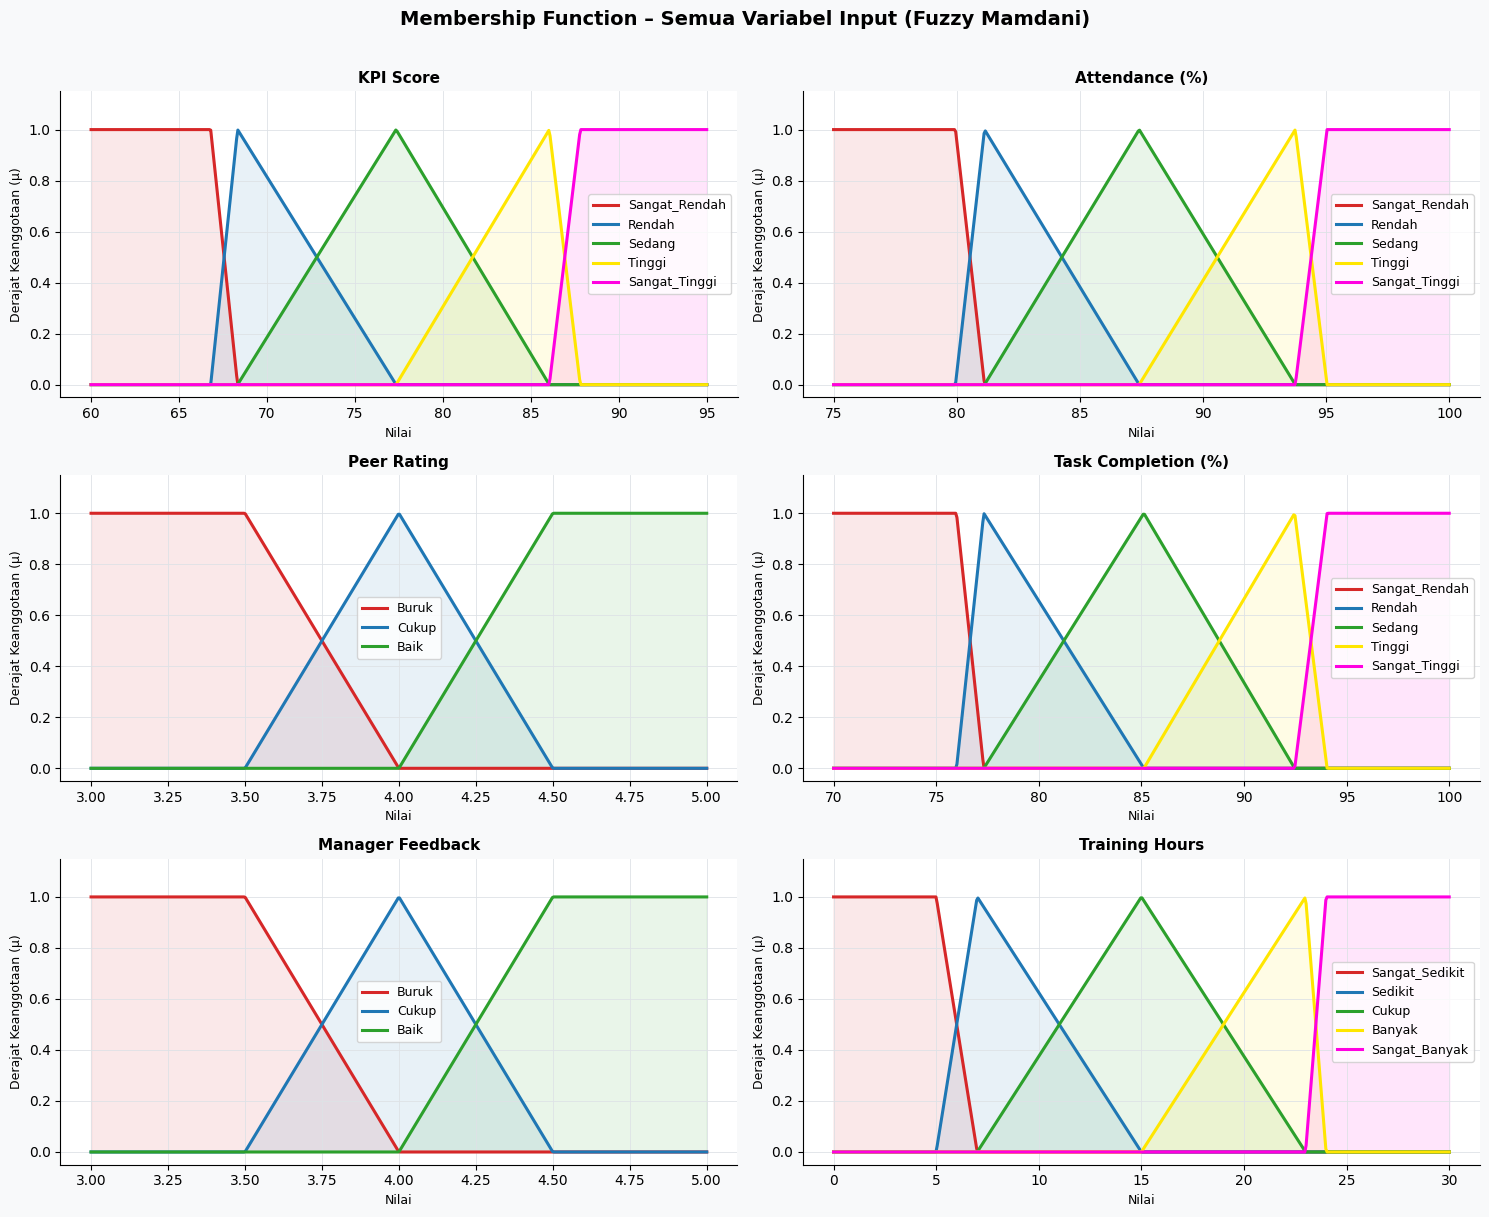

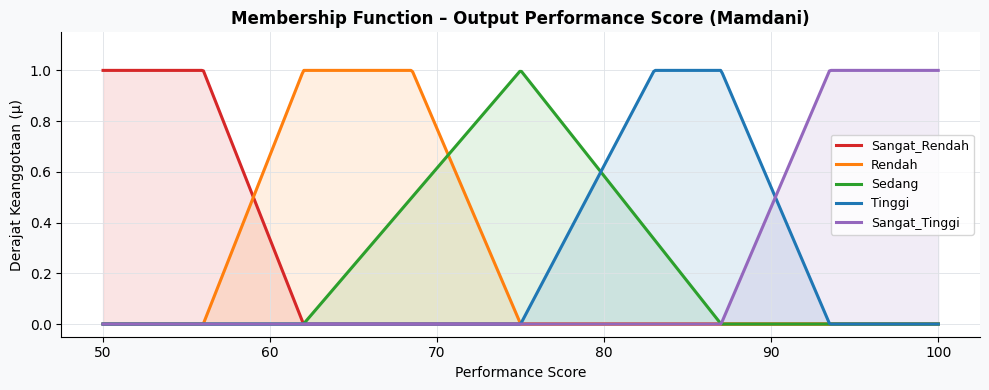

In [78]:
def mf_values(x_arr, params):
    """Hitung derajat keanggotaan untuk array x sesuai panjang params."""
    fn = trapmf if len(params) == 4 else trimf
    return [fn(x, *params) for x in x_arr]

RANGES = {
    'KPI Score': (60, 95), 'Attendance (%)': (75, 100),
    'Peer Rating': (3, 5), 'Task Completion (%)': (70, 100),
    'Manager Feedback': (3, 5), 'Training Hours': (0, 30),
}
LABEL_COLORS = ['#D62728', '#1F77B4', '#2CA02C', "#FFE600", "#FF00E1"]   # merah, biru, hijau

fig, axes = plt.subplots(3, 2, figsize=(15, 12), facecolor='#F8F9FA')
axes = axes.flatten()

for idx, (var, himpunan) in enumerate(MEMBERSHIP.items()):
    ax  = axes[idx]
    ax.set_facecolor('white')
    lo, hi = RANGES[var]
    x  = np.linspace(lo, hi, 500)

    for (nama, params), clr in zip(himpunan.items(), LABEL_COLORS):
        y = mf_values(x, params)
        ax.plot(x, y, color=clr, lw=2.2, label=nama)
        ax.fill_between(x, y, alpha=0.10, color=clr)

    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=9)
    ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, color='#DEE2E6', lw=0.6)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Membership Function – Semua Variabel Input (Fuzzy Mamdani)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Visualisasi MF Output Mamdani ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4), facecolor='#F8F9FA')
ax2.set_facecolor('white')
out_colors = ['#D62728', '#FF7F0E', '#2CA02C', '#1F77B4', '#9467BD']
for (nama, params), clr in zip(OUTPUT_MF.items(), out_colors):
    y = mf_values(OUTPUT_DOMAIN, params)
    ax2.plot(OUTPUT_DOMAIN, y, color=clr, lw=2.2, label=nama)
    ax2.fill_between(OUTPUT_DOMAIN, y, alpha=0.12, color=clr)
ax2.set_title('Membership Function – Output Performance Score (Mamdani)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Performance Score', fontsize=10)
ax2.set_ylabel('Derajat Keanggotaan (μ)', fontsize=10)
ax2.set_ylim(-0.05, 1.15)
ax2.legend(fontsize=9)
ax2.grid(True, color='#DEE2E6', lw=0.6)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 3. Fuzzifikasi

Fuzzifikasi adalah proses mengubah nilai input *crisp* menjadi **derajat keanggotaan** di setiap himpunan fuzzy yang telah didefinisikan. Hasilnya adalah dictionary berisi nilai μ (mu) untuk setiap himpunan per variabel.

In [79]:
def fuzzify(row: pd.Series) -> dict:
    """
    Fuzzifikasi satu baris data.
    Mengembalikan dict berisi derajat keanggotaan tiap himpunan
    untuk setiap variabel input.
    """
    kpi  = row['KPI Score']
    att  = row['Attendance (%)']
    peer = row['Peer Rating']
    task = row['Task Completion (%)']
    mgr  = row['Manager Feedback']
    trn  = row['Training Hours']

    mf = MEMBERSHIP   # alias pendek

    return {
        'kpi' : {
            'SR': trapmf(kpi,  *mf['KPI Score']['Sangat_Rendah']),
            'R': trimf(kpi,  *mf['KPI Score']['Rendah']),
            'S': trimf (kpi,  *mf['KPI Score']['Sedang']),
            'T': trimf(kpi,  *mf['KPI Score']['Tinggi']),
            'ST': trapmf(kpi,  *mf['KPI Score']['Sangat_Tinggi']),
        },
        'att' : {
            'SR': trapmf(att,  *mf['Attendance (%)']['Sangat_Rendah']),
            'R': trimf(att,  *mf['Attendance (%)']['Rendah']),
            'S': trimf (att,  *mf['Attendance (%)']['Sedang']),
            'T': trimf(att,  *mf['Attendance (%)']['Tinggi']),
            'ST': trapmf(att,  *mf['Attendance (%)']['Sangat_Tinggi']),
        },
        'peer': {
            'R': trapmf(peer, *mf['Peer Rating']['Buruk']),
            'S': trimf (peer, *mf['Peer Rating']['Cukup']),
            'T': trapmf(peer, *mf['Peer Rating']['Baik']),
        },
        'task': {
            'SR': trapmf(task, *mf['Task Completion (%)']['Sangat_Rendah']),
            'R': trimf(task, *mf['Task Completion (%)']['Rendah']),
            'S': trimf (task, *mf['Task Completion (%)']['Sedang']),
            'T': trimf(task, *mf['Task Completion (%)']['Tinggi']),
            'ST': trapmf(task, *mf['Task Completion (%)']['Sangat_Tinggi']),
        },
        'mgr' : {
            'R': trapmf(mgr,  *mf['Manager Feedback']['Buruk']),
            'S': trimf (mgr,  *mf['Manager Feedback']['Cukup']),
            'T': trapmf(mgr,  *mf['Manager Feedback']['Baik']),
        },
        'trn' : {
            'SR': trapmf(trn,  *mf['Training Hours']['Sangat_Sedikit']),
            'R': trimf(trn,  *mf['Training Hours']['Sedikit']),
            'S': trimf (trn,  *mf['Training Hours']['Cukup']),
            'T': trimf(trn,  *mf['Training Hours']['Banyak']),
            'ST': trapmf(trn,  *mf['Training Hours']['Sangat_Banyak']),
        },
    }

In [80]:
# ── Contoh fuzzifikasi pada 1 baris data ──────────────────────────
sample_row = pd.Series({
    'KPI Score': 85, 'Attendance (%)': 90, 'Peer Rating': 4.5,
    'Task Completion (%)': 92, 'Manager Feedback': 4.6, 'Training Hours': 18
})

f_sample = fuzzify(sample_row)

label_map = {
    'kpi':'KPI Score', 'att':'Attendance (%)', 'peer':'Peer Rating',
    'task':'Task Completion (%)', 'mgr':'Manager Feedback', 'trn':'Training Hours'
}
himpunan_map = {
    'kpi' :['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'att' :['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'peer':['Buruk','Cukup','Baik'],
    'task':['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'mgr' :['Buruk','Cukup','Baik'],
    'trn' :['Sangat Sedikit','Sedikit','Cukup','Banyak','Sangat Banyak'],
}

print('=== Hasil Fuzzifikasi Contoh Data ===')
for key, vals in f_sample.items():
    labels = himpunan_map[key]
    print(f'  {label_map[key]:<22} → ', end='')
    for lbl, (k, v) in zip(labels, vals.items()):
        print(f'{lbl}={v:.4f}  ', end='')
    print()

=== Hasil Fuzzifikasi Contoh Data ===
  KPI Score              → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.1206  Tinggi=0.8794  Sangat Tinggi=0.0000  
  Attendance (%)         → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.5915  Tinggi=0.4085  Sangat Tinggi=0.0000  
  Peer Rating            → Buruk=0.0000  Cukup=0.0000  Baik=1.0000  
  Task Completion (%)    → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.0639  Tinggi=0.9361  Sangat Tinggi=0.0000  
  Manager Feedback       → Buruk=0.0000  Cukup=0.0000  Baik=1.0000  
  Training Hours         → Sangat Sedikit=0.0000  Sedikit=0.0000  Cukup=0.6250  Banyak=0.3750  Sangat Banyak=0.0000  


---
## 4. Rule Base (Basis Aturan)

Sistem Fuzzy Mamdani menggunakan **48 rule** dengan format:

> **IF** *antecedent_1* **AND** *antecedent_2* **[AND ...]** **THEN** *output = himpunan fuzzy*

Dalam Mamdani, **output setiap rule adalah himpunan fuzzy** (bukan konstanta seperti Sugeno). Firing strength rule memotong (clip) himpunan output pada nilai tersebut.

**Operator AND** menggunakan fungsi **minimum** (t-norm standar Mamdani):
$$\mu_{rule} = \min(\mu_{A_1}, \mu_{A_2}, \ldots)$$

In [81]:
# Tampilkan daftar rule dalam format teks
RULE_DESCRIPTIONS = [
    # ── SANGAT TINGGI ──────────────────────────────────────────────
    'R01: IF KPI ST      AND Attendance ST  AND Task ST    THEN Sangat_Tinggi',
    'R02: IF KPI ST      AND Manager Baik   AND Peer Baik  THEN Sangat_Tinggi',
    'R03: IF KPI ST      AND Task ST        AND Manager T  THEN Sangat_Tinggi',
    'R04: IF KPI ST      AND Attendance ST  AND Manager T  THEN Sangat_Tinggi',
    'R05: IF Task ST     AND Manager T      AND Peer Baik  THEN Sangat_Tinggi',
    'R06: IF KPI ST      AND Attendance T   AND Task ST    THEN Sangat_Tinggi',
    'R07: IF KPI T       AND Attendance ST  AND Task ST    THEN Sangat_Tinggi',
    'R08: IF KPI ST      AND Task ST        AND Training T THEN Sangat_Tinggi',
    'R09: IF KPI ST      AND Attendance ST  AND Peer Baik  THEN Sangat_Tinggi',
    'R10: IF Task ST     AND Attendance ST  AND Manager T  THEN Sangat_Tinggi',
    # ── TINGGI ─────────────────────────────────────────────────────
    'R11: IF KPI T       AND Attendance T   AND Task T     THEN Tinggi',
    'R12: IF KPI T       AND Manager T      AND Task T     THEN Tinggi',
    'R13: IF KPI ST      AND Attendance S   AND Task T     THEN Tinggi',
    'R14: IF KPI T       AND Attendance ST  AND Task S     THEN Tinggi',
    'R15: IF Task T      AND Manager T      AND Attendance S THEN Tinggi',
    'R16: IF KPI T       AND Peer Baik      AND Attendance T THEN Tinggi',
    'R17: IF KPI T       AND Task T         AND Training T THEN Tinggi',
    'R18: IF KPI ST      AND Manager Cukup  AND Task T     THEN Tinggi',
    'R19: IF Attendance T AND Task ST       AND Manager S  THEN Tinggi',
    'R20: IF KPI T       AND Attendance T   AND Training ST THEN Tinggi',
    # ── SEDANG ─────────────────────────────────────────────────────
    'R21: IF KPI S       AND Attendance S   AND Task S     THEN Sedang',
    'R22: IF KPI T       AND Attendance R   AND Task S     THEN Sedang',
    'R23: IF KPI S       AND Attendance T   AND Task R     THEN Sedang',
    'R24: IF KPI R       AND Attendance ST  AND Task T     THEN Sedang',
    'R25: IF KPI S       AND Manager S      AND Task T     THEN Sedang',
    'R26: IF KPI S       AND Attendance S   AND Manager T  THEN Sedang',
    'R27: IF KPI T       AND Attendance S   AND Task R     THEN Sedang',
    'R28: IF Task S      AND Attendance S   AND Peer Cukup THEN Sedang',
    'R29: IF KPI S       AND Task S         AND Training S THEN Sedang',
    'R30: IF KPI R       AND Manager Baik   AND Task ST    THEN Sedang',
    # ── RENDAH ─────────────────────────────────────────────────────
    'R31: IF KPI R       AND Attendance R   AND Task R     THEN Rendah',
    'R32: IF KPI SR      AND Attendance S   AND Task S     THEN Rendah',
    'R33: IF KPI R       AND Manager S      AND Task R     THEN Rendah',
    'R34: IF KPI S       AND Attendance SR  AND Task R     THEN Rendah',
    'R35: IF KPI R       AND Task R         AND Training R THEN Rendah',
    'R36: IF KPI R       AND Attendance R   AND Peer Cukup THEN Rendah',
    'R37: IF Task R      AND Manager S      AND Attendance R THEN Rendah',
    'R38: IF KPI S       AND Attendance R   AND Task SR    THEN Rendah',
    'R39: IF KPI R       AND Manager Buruk  AND Attendance S THEN Rendah',
    'R40: IF Task SR     AND Attendance R   AND Training S THEN Rendah',
    # ── SANGAT RENDAH ──────────────────────────────────────────────
    'R41: IF KPI SR      AND Attendance SR  AND Task SR    THEN Sangat_Rendah',
    'R42: IF KPI SR      AND Manager Buruk  AND Task R     THEN Sangat_Rendah',
    'R43: IF KPI SR      AND Attendance R   AND Task SR    THEN Sangat_Rendah',
    'R44: IF KPI R       AND Attendance SR  AND Task SR    THEN Sangat_Rendah',
    'R45: IF KPI SR      AND Task SR        AND Training SR THEN Sangat_Rendah',
    'R46: IF KPI SR      AND Attendance SR  AND Manager Buruk THEN Sangat_Rendah',
    'R47: IF Task SR     AND Manager Buruk  AND Peer Buruk THEN Sangat_Rendah',
    'R48: IF KPI SR      AND Attendance SR  AND Peer Buruk THEN Sangat_Rendah',
]

print(f'Total rules : {len(RULE_DESCRIPTIONS)}\n')
for r in RULE_DESCRIPTIONS:
    print(' ', r)

Total rules : 48

  R01: IF KPI ST      AND Attendance ST  AND Task ST    THEN Sangat_Tinggi
  R02: IF KPI ST      AND Manager Baik   AND Peer Baik  THEN Sangat_Tinggi
  R03: IF KPI ST      AND Task ST        AND Manager T  THEN Sangat_Tinggi
  R04: IF KPI ST      AND Attendance ST  AND Manager T  THEN Sangat_Tinggi
  R05: IF Task ST     AND Manager T      AND Peer Baik  THEN Sangat_Tinggi
  R06: IF KPI ST      AND Attendance T   AND Task ST    THEN Sangat_Tinggi
  R07: IF KPI T       AND Attendance ST  AND Task ST    THEN Sangat_Tinggi
  R08: IF KPI ST      AND Task ST        AND Training T THEN Sangat_Tinggi
  R09: IF KPI ST      AND Attendance ST  AND Peer Baik  THEN Sangat_Tinggi
  R10: IF Task ST     AND Attendance ST  AND Manager T  THEN Sangat_Tinggi
  R11: IF KPI T       AND Attendance T   AND Task T     THEN Tinggi
  R12: IF KPI T       AND Manager T      AND Task T     THEN Tinggi
  R13: IF KPI ST      AND Attendance S   AND Task T     THEN Tinggi
  R14: IF KPI T       AND At

---
## 5. Inferensi Mamdani

Setiap rule dievaluasi menggunakan operator **minimum** pada antecedent-nya. Hasil evaluasi adalah **firing strength (α)** — seberapa kuat rule tersebut berlaku untuk input yang diberikan.

Pada Mamdani, firing strength digunakan untuk **memotong (clip)** himpunan fuzzy output menggunakan operasi minimum:
$$\mu_{\text{output clipped}}(z) = \min(\alpha_{rule}, \mu_{\text{output}}(z))$$

Hasil potongan semua rule kemudian **diagregasi** (digabungkan) menggunakan operasi **maximum**:
$$\mu_{\text{agregat}}(z) = \max_i \left[ \mu_{\text{rule}_i \text{ clipped}}(z) \right]$$

In [82]:
def evaluate_rules(f: dict) -> list:
    """
    Evaluasi 48 rule fuzzy Mamdani.
    Key himpunan:
      SR = Sangat Rendah   R = Rendah   S = Sedang   T = Tinggi   ST = Sangat Tinggi
      (Peer Rating & Manager Feedback tetap 3 level: R=Buruk, S=Cukup, T=Baik)
    Input  : f = hasil fuzzify()
    Output : list of (firing_strength, nama_output_himpunan)
             — berbeda dari Sugeno yang mengembalikan (strength, konstanta)
    """
    rules = [
        # ── SANGAT TINGGI ──────────────────────────────────────────
        (min(f['kpi']['ST'], f['att']['ST'], f['task']['ST']),          'Sangat_Tinggi'),  # R01
        (min(f['kpi']['ST'], f['mgr']['T'],  f['peer']['T']),           'Sangat_Tinggi'),  # R02
        (min(f['kpi']['ST'], f['task']['ST'], f['mgr']['T']),           'Sangat_Tinggi'),  # R03
        (min(f['kpi']['ST'], f['att']['ST'], f['mgr']['T']),            'Sangat_Tinggi'),  # R04
        (min(f['task']['ST'],f['mgr']['T'],  f['peer']['T']),           'Sangat_Tinggi'),  # R05
        (min(f['kpi']['ST'], f['att']['T'],  f['task']['ST']),          'Sangat_Tinggi'),  # R06
        (min(f['kpi']['T'],  f['att']['ST'], f['task']['ST']),          'Sangat_Tinggi'),  # R07
        (min(f['kpi']['ST'], f['task']['ST'], f['trn']['T']),           'Sangat_Tinggi'),  # R08
        (min(f['kpi']['ST'], f['att']['ST'], f['peer']['T']),           'Sangat_Tinggi'),  # R09
        (min(f['task']['ST'],f['att']['ST'], f['mgr']['T']),            'Sangat_Tinggi'),  # R10

        # ── TINGGI ─────────────────────────────────────────────────
        (min(f['kpi']['T'],  f['att']['T'],  f['task']['T']),           'Tinggi'),         # R11
        (min(f['kpi']['T'],  f['mgr']['T'],  f['task']['T']),           'Tinggi'),         # R12
        (min(f['kpi']['ST'], f['att']['S'],  f['task']['T']),           'Tinggi'),         # R13
        (min(f['kpi']['T'],  f['att']['ST'], f['task']['S']),           'Tinggi'),         # R14
        (min(f['task']['T'], f['mgr']['T'],  f['att']['S']),            'Tinggi'),         # R15
        (min(f['kpi']['T'],  f['peer']['T'], f['att']['T']),            'Tinggi'),         # R16
        (min(f['kpi']['T'],  f['task']['T'], f['trn']['T']),            'Tinggi'),         # R17
        (min(f['kpi']['ST'], f['mgr']['S'],  f['task']['T']),           'Tinggi'),         # R18
        (min(f['att']['T'],  f['task']['ST'], f['mgr']['S']),           'Tinggi'),         # R19
        (min(f['kpi']['T'],  f['att']['T'],  f['trn']['ST']),           'Tinggi'),         # R20

        # ── SEDANG ─────────────────────────────────────────────────
        (min(f['kpi']['S'],  f['att']['S'],  f['task']['S']),           'Sedang'),         # R21
        (min(f['kpi']['T'],  f['att']['R'],  f['task']['S']),           'Sedang'),         # R22
        (min(f['kpi']['S'],  f['att']['T'],  f['task']['R']),           'Sedang'),         # R23
        (min(f['kpi']['R'],  f['att']['ST'], f['task']['T']),           'Sedang'),         # R24
        (min(f['kpi']['S'],  f['mgr']['S'],  f['task']['T']),           'Sedang'),         # R25
        (min(f['kpi']['S'],  f['att']['S'],  f['mgr']['T']),            'Sedang'),         # R26
        (min(f['kpi']['T'],  f['att']['S'],  f['task']['R']),           'Sedang'),         # R27
        (min(f['task']['S'], f['att']['S'],  f['peer']['S']),           'Sedang'),         # R28
        (min(f['kpi']['S'],  f['task']['S'], f['trn']['S']),            'Sedang'),         # R29
        (min(f['kpi']['R'],  f['mgr']['T'],  f['task']['ST']),          'Sedang'),         # R30

        # ── RENDAH ─────────────────────────────────────────────────
        (min(f['kpi']['R'],  f['att']['R'],  f['task']['R']),           'Rendah'),         # R31
        (min(f['kpi']['SR'], f['att']['S'],  f['task']['S']),           'Rendah'),         # R32
        (min(f['kpi']['R'],  f['mgr']['S'],  f['task']['R']),           'Rendah'),         # R33
        (min(f['kpi']['S'],  f['att']['SR'], f['task']['R']),           'Rendah'),         # R34
        (min(f['kpi']['R'],  f['task']['R'], f['trn']['R']),            'Rendah'),         # R35
        (min(f['kpi']['R'],  f['att']['R'],  f['peer']['S']),           'Rendah'),         # R36
        (min(f['task']['R'], f['mgr']['S'],  f['att']['R']),            'Rendah'),         # R37
        (min(f['kpi']['S'],  f['att']['R'],  f['task']['SR']),          'Rendah'),         # R38
        (min(f['kpi']['R'],  f['mgr']['R'],  f['att']['S']),            'Rendah'),         # R39
        (min(f['task']['SR'],f['att']['R'],  f['trn']['S']),            'Rendah'),         # R40

        # ── SANGAT RENDAH ──────────────────────────────────────────
        (min(f['kpi']['SR'], f['att']['SR'], f['task']['SR']),          'Sangat_Rendah'),  # R41
        (min(f['kpi']['SR'], f['mgr']['R'],  f['task']['R']),           'Sangat_Rendah'),  # R42
        (min(f['kpi']['SR'], f['att']['R'],  f['task']['SR']),          'Sangat_Rendah'),  # R43
        (min(f['kpi']['R'],  f['att']['SR'], f['task']['SR']),          'Sangat_Rendah'),  # R44
        (min(f['kpi']['SR'], f['task']['SR'], f['trn']['SR']),          'Sangat_Rendah'),  # R45
        (min(f['kpi']['SR'], f['att']['SR'], f['mgr']['R']),            'Sangat_Rendah'),  # R46
        (min(f['task']['SR'],f['mgr']['R'],  f['peer']['R']),           'Sangat_Rendah'),  # R47
        (min(f['kpi']['SR'], f['att']['SR'], f['peer']['R']),           'Sangat_Rendah'),  # R48
    ]
    return rules

In [83]:
# Contoh inferensi pada data sampel
rules_sample = evaluate_rules(f_sample)

print('=== Firing Strength Tiap Rule (Contoh Data) ===')
print(f"{'Rule':<6} {'Firing Strength':>16} {'Output Himpunan':>18}")
print('-' * 44)
for i, (w, label) in enumerate(rules_sample, 1):
    active = ' ← aktif' if w > 0 else ''
    print(f"R{i:02d}    {w:>16.4f} {label:>18}{active}")

=== Firing Strength Tiap Rule (Contoh Data) ===
Rule    Firing Strength    Output Himpunan
--------------------------------------------
R01              0.0000      Sangat_Tinggi
R02              0.0000      Sangat_Tinggi
R03              0.0000      Sangat_Tinggi
R04              0.0000      Sangat_Tinggi
R05              0.0000      Sangat_Tinggi
R06              0.0000      Sangat_Tinggi
R07              0.0000      Sangat_Tinggi
R08              0.0000      Sangat_Tinggi
R09              0.0000      Sangat_Tinggi
R10              0.0000      Sangat_Tinggi
R11              0.4085             Tinggi ← aktif
R12              0.8794             Tinggi ← aktif
R13              0.0000             Tinggi
R14              0.0000             Tinggi
R15              0.5915             Tinggi ← aktif
R16              0.4085             Tinggi ← aktif
R17              0.3750             Tinggi ← aktif
R18              0.0000             Tinggi
R19              0.0000             Tinggi
R20    

---
## 6. Defuzzifikasi – Centroid (Center of Gravity)

Pada Mamdani, defuzzifikasi menggunakan metode **Centroid** (Center of Area / COA):

$$\text{Output} = \frac{\int z \cdot \mu_{\text{agregat}}(z)\, dz}{\int \mu_{\text{agregat}}(z)\, dz}$$

Prosesnya:
1. **Agregasi**: untuk setiap titik pada domain output, ambil nilai maksimum dari semua potongan rule yang aktif.
2. **Centroid**: hitung titik berat dari kurva hasil agregasi.

Ini berbeda dari Sugeno yang hanya menghitung Weighted Average dari konstanta crisp.

In [84]:
def aggregate(rules: list, domain: np.ndarray) -> np.ndarray:
    """
    Agregasi Mamdani: clip tiap output himpunan pada firing strength,
    lalu ambil maksimum di seluruh rule (union).
    """
    aggregated = np.zeros(len(domain))
    for alpha, label in rules:
        if alpha <= 0:
            continue
        params = OUTPUT_MF[label]
        fn = trapmf if len(params) == 4 else trimf
        clipped = np.array([min(alpha, fn(z, *params)) for z in domain])
        aggregated = np.maximum(aggregated, clipped)
    return aggregated


def defuzzify_centroid(aggregated: np.ndarray, domain: np.ndarray) -> float:
    """
    Defuzzifikasi Centroid (Center of Gravity).
    Jika seluruh area = 0, kembalikan nilai tengah domain (fallback).
    """
    total_area = np.trapezoid(aggregated, domain)
    if total_area == 0:
        return float(np.mean(domain))   # fallback = titik tengah domain
    return float(np.trapezoid(aggregated * domain, domain) / total_area)


def predict_one(row: pd.Series) -> float:
    """Pipeline lengkap: fuzzifikasi → inferensi → agregasi → defuzzifikasi untuk 1 baris."""
    f          = fuzzify(row)
    rules      = evaluate_rules(f)
    aggregated = aggregate(rules, OUTPUT_DOMAIN)
    return defuzzify_centroid(aggregated, OUTPUT_DOMAIN)

=== Proses Defuzzifikasi Centroid (Mamdani) ===
  Luas area agregat = 12.1932
  Centroid (output) = 82.5893

  Predicted Performance Score = 82.59  →  Kategori: Tinggi


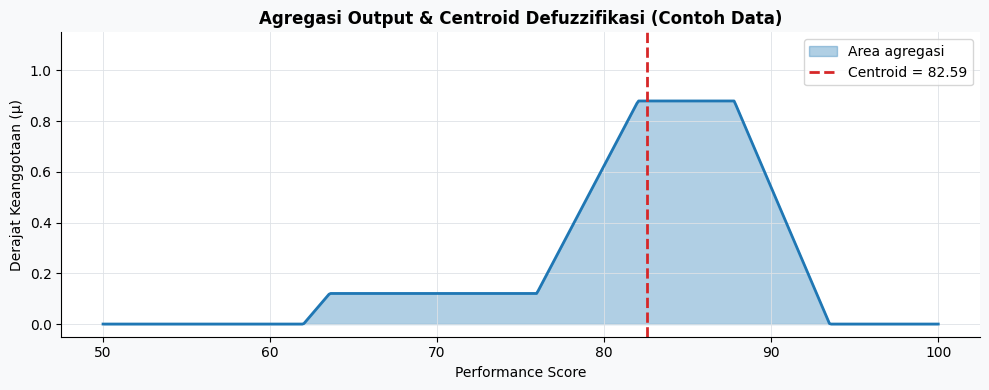

In [85]:
# Contoh defuzzifikasi pada data sampel
rules_sample  = evaluate_rules(f_sample)
agg_sample    = aggregate(rules_sample, OUTPUT_DOMAIN)
result_sample = defuzzify_centroid(agg_sample, OUTPUT_DOMAIN)

total_area = np.trapezoid(agg_sample, OUTPUT_DOMAIN)

print('=== Proses Defuzzifikasi Centroid (Mamdani) ===')
print(f'  Luas area agregat = {total_area:.4f}')
print(f'  Centroid (output) = {result_sample:.4f}')
print()

if   result_sample >= 90:
    kategori =  'Sangat Tinggi'
elif result_sample >= 80:
    kategori = 'Tinggi'
elif result_sample >= 70:
    kategori = 'Sedang'
elif result_sample >= 60:
    kategori = 'Rendah'
else:
    kategori = 'Sangat Rendah'

print(f'  Predicted Performance Score = {result_sample:.2f}  →  Kategori: {kategori}')

# ── Visualisasi area agregasi + garis centroid ────────────────────
fig, ax = plt.subplots(figsize=(10, 4), facecolor='#F8F9FA')
ax.set_facecolor('white')
ax.fill_between(OUTPUT_DOMAIN, agg_sample, alpha=0.35, color='#1F77B4', label='Area agregasi')
ax.plot(OUTPUT_DOMAIN, agg_sample, color='#1F77B4', lw=2)
ax.axvline(result_sample, color='#D62728', lw=2, ls='--',
           label=f'Centroid = {result_sample:.2f}')
ax.set_title('Agregasi Output & Centroid Defuzzifikasi (Contoh Data)', fontsize=12, fontweight='bold')
ax.set_xlabel('Performance Score', fontsize=10)
ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=10)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=10)
ax.grid(True, color='#DEE2E6', lw=0.6)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. Prediksi pada Seluruh Dataset

Pipeline fuzzy Mamdani diterapkan pada semua 5.000 baris data untuk menghasilkan prediksi `Performance Score` yang kemudian dibandingkan dengan nilai aktual.

In [86]:
print('Menjalankan prediksi fuzzy Mamdani pada seluruh dataset...')

df['Predicted_Mamdani'] = df.apply(predict_one, axis=1)

# Kategori 5 level
def to_kategori(score):
    if   score >= 90:
        return 'Sangat Tinggi'
    elif score >= 80:
        return 'Tinggi'
    elif score >= 70:
        return 'Sedang'
    elif score >= 60:
        return 'Rendah'
    else:
        return 'Sangat Rendah'

df['Kategori_Aktual']   = df[OUTPUT_COL].apply(to_kategori)
df['Kategori_Prediksi'] = df['Predicted_Mamdani'].apply(to_kategori)

print(f'Selesai. Total baris diproses: {len(df):,}')
print()
print('=== Sample 10 Baris Hasil Prediksi ===')
print(df[[OUTPUT_COL, 'Predicted_Mamdani', 'Kategori_Aktual', 'Kategori_Prediksi']].head(10).to_string())

Menjalankan prediksi fuzzy Mamdani pada seluruh dataset...
Selesai. Total baris diproses: 5,000

=== Sample 10 Baris Hasil Prediksi ===
   Performance Score  Predicted_Mamdani Kategori_Aktual Kategori_Prediksi
0                 61          94.279449          Rendah     Sangat Tinggi
1                 91          75.000000   Sangat Tinggi            Sedang
2                100          55.112885   Sangat Tinggi     Sangat Rendah
3                100          75.000000   Sangat Tinggi            Sedang
4                 80          74.522441          Tinggi            Sedang
5                 53          69.161702   Sangat Rendah            Rendah
6                 59          75.000000   Sangat Rendah            Sedang
7                 98          93.550377   Sangat Tinggi     Sangat Tinggi
8                 83          75.000000          Tinggi            Sedang
9                 70          73.543693          Sedang            Sedang


---
## 8. Evaluasi Performa – MAE, MSE, RMSE

Evaluasi dilakukan menggunakan tiga metrik regresi standar:

$$\text{MAE}  = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$\text{MSE}  = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

In [87]:
actuals   = df[OUTPUT_COL].values
predicted = df['Predicted_Mamdani'].values
errors    = actuals - predicted

MAE  = np.mean(np.abs(errors))
MSE  = np.mean(errors ** 2)
RMSE = np.sqrt(MSE)

print('=' * 40)
print('   EVALUASI FUZZY MAMDANI')
print('=' * 40)
print(f'   MAE  = {MAE:.4f}')
print(f'   MSE  = {MSE:.4f}')
print(f'   RMSE = {RMSE:.4f}')
print('=' * 40)
print(f'   Range aktual   : [{actuals.min():.1f}, {actuals.max():.1f}]')
print(f'   Range prediksi : [{predicted.min():.2f}, {predicted.max():.2f}]')
print(f'   Rata-rata error: {np.mean(errors):.4f}')

   EVALUASI FUZZY MAMDANI
   MAE  = 14.9487
   MSE  = 331.7720
   RMSE = 18.2146
   Range aktual   : [50.0, 100.0]
   Range prediksi : [54.67, 94.94]
   Rata-rata error: 0.1434


---
## 9. Visualisasi Hasil

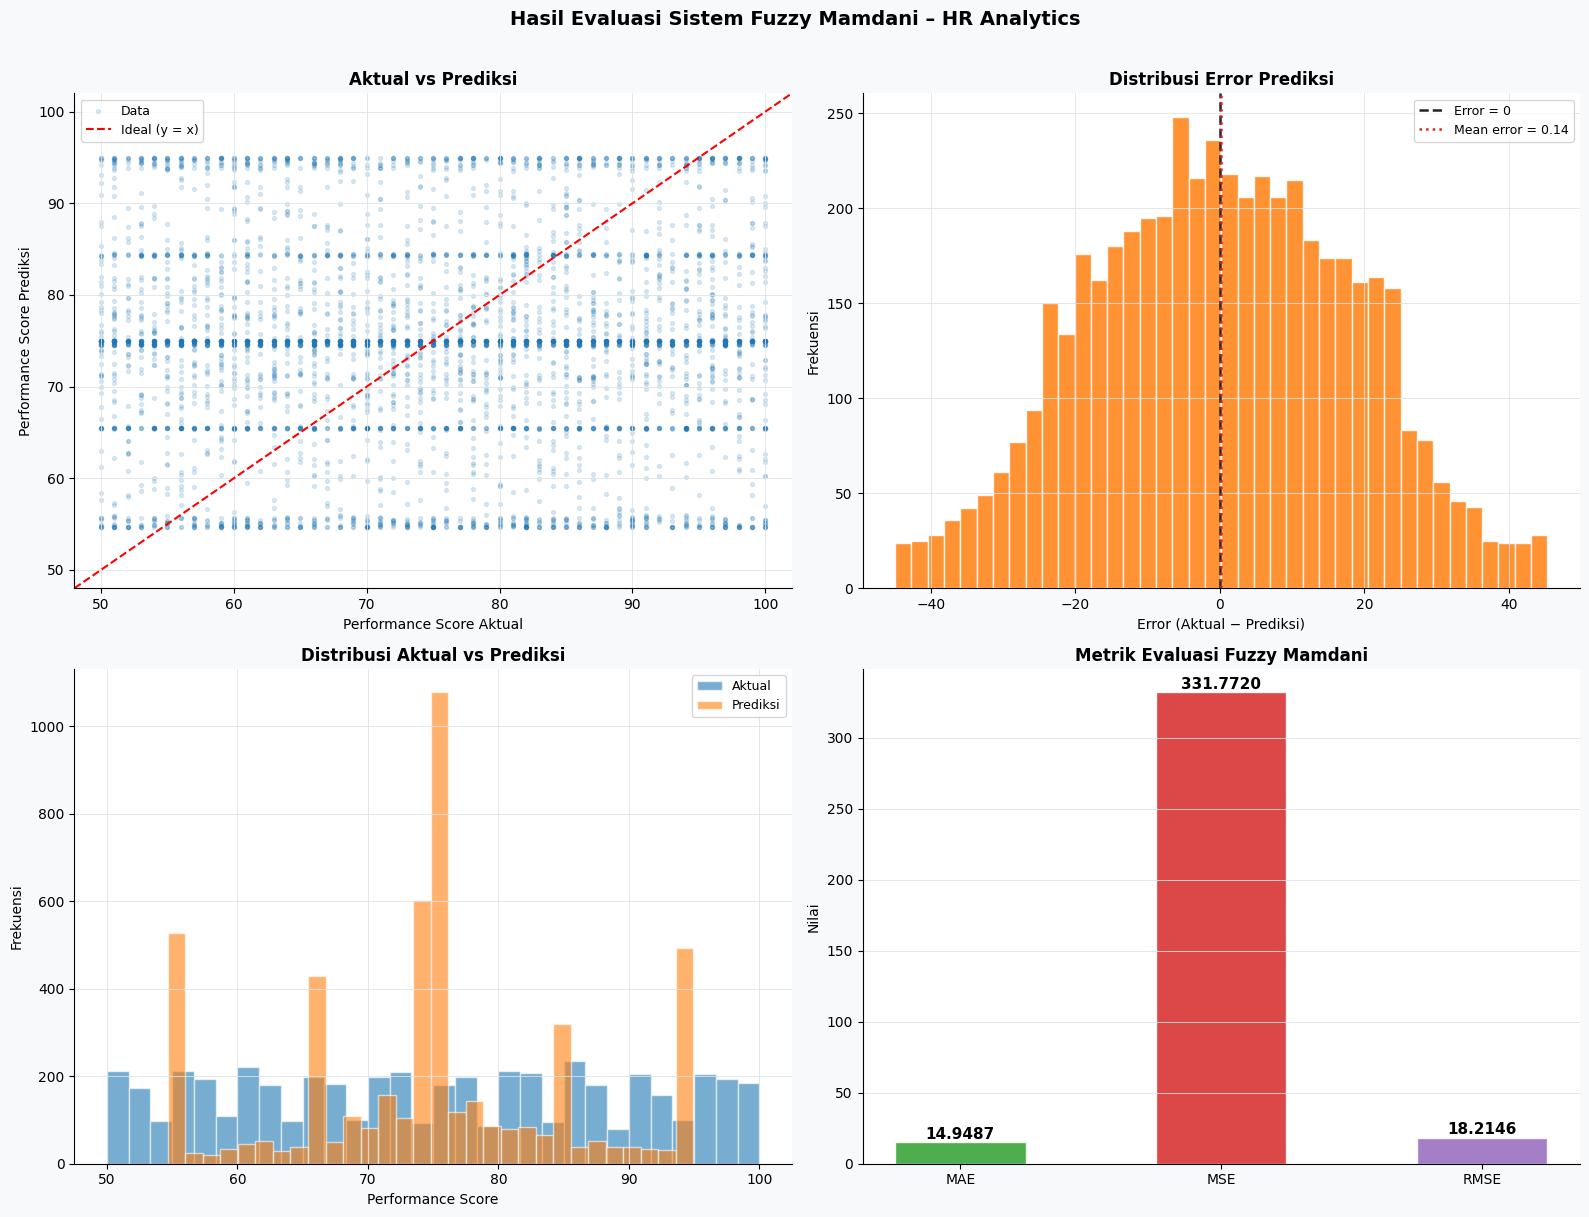

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#F8F9FA')

# ── 9.1 Scatter: Aktual vs Prediksi ───────────────────────────────
ax1 = axes[0, 0]
ax1.set_facecolor('white')
ax1.scatter(actuals, predicted, alpha=0.15, s=8, color='#1F77B4', label='Data')
lims = [min(actuals.min(), predicted.min()) - 2,
        max(actuals.max(), predicted.max()) + 2]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Ideal (y = x)')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Performance Score Aktual', fontsize=10)
ax1.set_ylabel('Performance Score Prediksi', fontsize=10)
ax1.set_title('Aktual vs Prediksi', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, color='#DEE2E6', lw=0.6)
ax1.spines[['top', 'right']].set_visible(False)

# ── 9.2 Histogram Error ───────────────────────────────────────────
ax2 = axes[0, 1]
ax2.set_facecolor('white')
ax2.hist(errors, bins=40, color='#FF7F0E', edgecolor='white', alpha=0.85)
ax2.axvline(0,           color='#212529', lw=1.8, ls='--', label='Error = 0')
ax2.axvline(np.mean(errors), color='#D62728', lw=1.8, ls=':',
            label=f'Mean error = {np.mean(errors):.2f}')
ax2.set_xlabel('Error (Aktual − Prediksi)', fontsize=10)
ax2.set_ylabel('Frekuensi', fontsize=10)
ax2.set_title('Distribusi Error Prediksi', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, color='#DEE2E6', lw=0.6)
ax2.spines[['top', 'right']].set_visible(False)

# ── 9.3 Distribusi Prediksi vs Aktual ─────────────────────────────
ax3 = axes[1, 0]
ax3.set_facecolor('white')
ax3.hist(actuals,   bins=30, alpha=0.6, color='#1F77B4', label='Aktual',   edgecolor='white')
ax3.hist(predicted, bins=30, alpha=0.6, color='#FF7F0E', label='Prediksi', edgecolor='white')
ax3.set_xlabel('Performance Score', fontsize=10)
ax3.set_ylabel('Frekuensi', fontsize=10)
ax3.set_title('Distribusi Aktual vs Prediksi', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, color='#DEE2E6', lw=0.6)
ax3.spines[['top', 'right']].set_visible(False)

# ── 9.4 Bar Metrik Evaluasi ───────────────────────────────────────
ax4 = axes[1, 1]
ax4.set_facecolor('white')
metrik = ['MAE', 'MSE', 'RMSE']
nilai  = [MAE, MSE, RMSE]
colors_bar = ['#2CA02C', '#D62728', '#9467BD']
bars = ax4.bar(metrik, nilai, color=colors_bar, edgecolor='white', alpha=0.85, width=0.5)
for bar, val in zip(bars, nilai):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_title('Metrik Evaluasi Fuzzy Mamdani', fontsize=12, fontweight='bold')
ax4.set_ylabel('Nilai', fontsize=10)
ax4.grid(True, axis='y', color='#DEE2E6', lw=0.6)
ax4.spines[['top', 'right']].set_visible(False)

fig.suptitle('Hasil Evaluasi Sistem Fuzzy Mamdani – HR Analytics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Ringkasan Sistem Fuzzy Mamdani

Cell ini mencetak ringkasan lengkap sistem yang telah dibangun — berguna sebagai acuan saat penggabungan notebook dan penyusunan laporan.

In [89]:
print('=' * 55)
print('        RINGKASAN SISTEM FUZZY MAMDANI')
print('=' * 55)
print(f'  Metode           : Fuzzy Mamdani (Linguistic / Klasik)')
print(f'  Total data       : {len(df):,} baris')
print(f'  Variabel input   : {len(INPUT_COLS)} variabel')
for c in INPUT_COLS:
    print(f'                     - {c}')
print(f'  Variabel output  : {OUTPUT_COL}')
print(f'  Jumlah himpunan  : 3–5 per variabel input')
print(f'  Fungsi keangg.   : Triangular & Trapezoidal')
print(f'  Jumlah rule      : 48 rule')
print(f'  Operator AND     : Minimum (t-norm)')
print(f'  Output per rule  : Himpunan fuzzy (clipped)')
print(f'  Domain output    : [50, 100] ({len(OUTPUT_DOMAIN)} titik)')
print(f'  Defuzzifikasi    : Centroid (Center of Gravity)')
print('-' * 55)
print(f'  MAE              : {MAE:.4f}')
print(f'  MSE              : {MSE:.4f}')
print(f'  RMSE             : {RMSE:.4f}')
print('=' * 55)

        RINGKASAN SISTEM FUZZY MAMDANI
  Metode           : Fuzzy Mamdani (Linguistic / Klasik)
  Total data       : 5,000 baris
  Variabel input   : 6 variabel
                     - KPI Score
                     - Attendance (%)
                     - Peer Rating
                     - Task Completion (%)
                     - Manager Feedback
                     - Training Hours
  Variabel output  : Performance Score
  Jumlah himpunan  : 3–5 per variabel input
  Fungsi keangg.   : Triangular & Trapezoidal
  Jumlah rule      : 48 rule
  Operator AND     : Minimum (t-norm)
  Output per rule  : Himpunan fuzzy (clipped)
  Domain output    : [50, 100] (500 titik)
  Defuzzifikasi    : Centroid (Center of Gravity)
-------------------------------------------------------
  MAE              : 14.9487
  MSE              : 331.7720
  RMSE             : 18.2146


In [90]:
low_weight = []
for _, row in df.iterrows():
    f = fuzzify(row)
    rules = evaluate_rules(f)
    total_area = np.trapezoid(aggregate(rules, OUTPUT_DOMAIN), OUTPUT_DOMAIN)
    low_weight.append(total_area)

df['total_area'] = low_weight
print(df['total_area'].describe())
print("Baris dengan total area < 0.1:", (df['total_area'] < 0.1).sum())

count    5000.000000
mean        6.671453
std         4.806029
min         0.000000
25%         2.280011
50%         7.252476
75%        10.012442
max        22.243239
Name: total_area, dtype: float64
Baris dengan total area < 0.1: 980


---
# Implementasi Fuzzy Sugeno
Menggunakan dataset dan membership yang sama agar perbandingan kedua metode bersifat adil.

In [91]:
# ── Load & seleksi kolom ───────────────────────────────────────────
INPUT_COLS = ['KPI Score', 'Attendance (%)', 'Peer Rating',
              'Task Completion (%)', 'Manager Feedback', 'Training Hours']
OUTPUT_COL = 'Performance Score'

raw = pd.read_csv('Employee_Performance_Dataset.csv')
df  = raw[INPUT_COLS + [OUTPUT_COL]].dropna().reset_index(drop=True)

print(f'Shape dataset : {df.shape}')
df.head()

Shape dataset : (5000, 7)


,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Manager Feedback,Training Hours,Performance Score
0,91.03,94.40,4.5,78.19,3.7,18,61
1,83.36,78.45,4.7,71.39,4.5,15,91
2,65.39,99.50,4.4,80.20,3.5,7,100
3,82.90,79.83,4.3,71.51,5.0,9,100
4,90.90,89.92,3.7,78.03,3.1,29,80


---
## 2. Membership Functions (Fungsi Keanggotaan)

Dua bentuk fungsi keanggotaan digunakan:
- **Trapezoidal (`trapmf`)** — untuk himpunan ujung kiri (bahu kiri) dan ujung kanan (bahu kanan), agar nilai ekstrem domain tetap memiliki derajat keanggotaan = 1.
- **Triangular (`trimf`)** — untuk himpunan tengah (*Sedang / Cukup*).

Batas-batas ditentukan berdasarkan **Q1, Median, Q3** dari statistik deskriptif data aktual (pendekatan *percentile-based*).

In [92]:
def trimf(x: float, a: float, b: float, c: float) -> float:
    """
    Triangular Membership Function.
    Naik linear dari a ke b (puncak = 1), turun linear dari b ke c.
    """
    left  = (x - a) / (b - a) if b != a else 1.0
    right = (c - x) / (c - b) if c != b else 1.0
    return float(max(0.0, min(left, right)))


def trapmf(x: float, a: float, b: float, c: float, d: float) -> float:
    """
    Trapezoidal Membership Function.
    - Bahu kiri  (a == b): plateau dimulai dari awal domain.
    - Bahu kanan (c == d): plateau hingga akhir domain.
    - Normal     (a < b, c < d): naik a→b, plateau b–c, turun c→d.
    """
    # Bahu kiri
    if a == b:
        if x <= c:       return 1.0
        elif c < x < d:  return (d - x) / (d - c)
        return 0.0
    # Bahu kanan
    if c == d:
        if x >= b:       return 1.0
        elif a < x < b:  return (x - a) / (b - a)
        return 0.0
    # Trapezoid normal
    if   x <= a or x >= d: return 0.0
    elif a < x <= b:       return (x - a) / (b - a)
    elif b < x <= c:       return 1.0
    elif c < x <  d:       return (d - x) / (d - c)
    return 0.0

### 2.1 Parameter Membership Function

Parameter batas setiap himpunan disimpan dalam dictionary `MEMBERSHIP` yang bersumber dari notebook Preprocessing.

In [93]:
MEMBERSHIP = {
    'KPI Score': {
        # Range: [60.01, 94.99]  Q1=68.33  Median=77.34  Q3=86.05
        'Sangat_Rendah' : [60, 60, 66.80, 68.33], #trapezoidal – bahu kiri
        'Rendah' : [66.80, 68.33, 77.34],   # triangular – bahu kiri
        'Sedang' : [68.33, 77.34, 86.05],   # triangular
        'Tinggi' : [77.34, 86.05, 87.81],   # triangular
        'Sangat_Tinggi' : [86.05, 87.81, 95.00, 95.00],   # trapezoidal – bahu kanan
    },
    'Attendance (%)': {
        # Range: [75.01, 100.00]  Q1=81.13  Median=87.41  Q3=93.75
        'Sangat_Rendah' : [75, 75, 79.95, 81.13],
        'Rendah' : [79.95, 81.13, 87.41],
        'Sedang' : [81.13, 87.41, 93.75],
        'Tinggi' : [87.41, 93.75, 95.04],
        'Sangat_Tinggi' : [93.75, 95.04, 100, 100],
    },
    'Peer Rating': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Task Completion (%)': {
        # Range: [70.01, 100.00]  Q1=77.32  Median=85.12  Q3=92.47
        'Sangat_Rendah' : [70, 70, 75.99, 77.32],
        'Rendah' : [75.99, 77.32, 85.12],
        'Sedang' : [77.32, 85.12, 92.47],
        'Tinggi' : [85.12, 92.47, 94.05],
        'Sangat_Tinggi' : [92.47, 94.05, 100, 100],
    },
    'Manager Feedback': {
        # Range: [3.00, 5.00]  Q1=3.50  Median=4.00  Q3=4.50
        'Buruk'  : [3.00, 3.00, 3.50, 4.00],
        'Cukup'  : [3.50, 4.00, 4.50],
        'Baik'   : [4.00, 4.50, 5.00, 5.00],
    },
    'Training Hours': {
        # Range: [0, 30]  Q1=7.00  Median=15.00  Q3=23.00
        'Sangat_Sedikit' : [0, 0, 5, 7],
        'Sedikit' : [5, 7, 15],
        'Cukup' : [7, 15, 23],
        'Banyak' : [15, 23, 24],
        'Sangat_Banyak' : [23, 24, 30, 30],
    },
}

# Output Sugeno – konstanta crisp (Order-0)
# Ditentukan dari statistik Performance Score: min=50, Q1=62, Med=75, Q3=87, max=100
# 4 level output agar rule base lebih ekspresif
Z = {
    'Sangat_Rendah': 56.0,   # tengah [50, 62]
    'Rendah'       : 68.5,   # tengah [62, 75]
    'Sedang'       : 75.0,   # median Performance Score
    'Tinggi'       : 83.0,   # tengah [75, 87]
    'Sangat_Tinggi': 93.5,   # tengah [87, 100]
}
print('Parameter membership function dimuat.')
print('Output konstanta Sugeno:', Z)

Parameter membership function dimuat.
Output konstanta Sugeno: {'Sangat_Rendah': 56.0, 'Rendah': 68.5, 'Sedang': 75.0, 'Tinggi': 83.0, 'Sangat_Tinggi': 93.5}


### 2.2 Visualisasi Membership Function

Kurva membership function divisualisasikan untuk semua 6 variabel input agar dapat divalidasi secara visual.

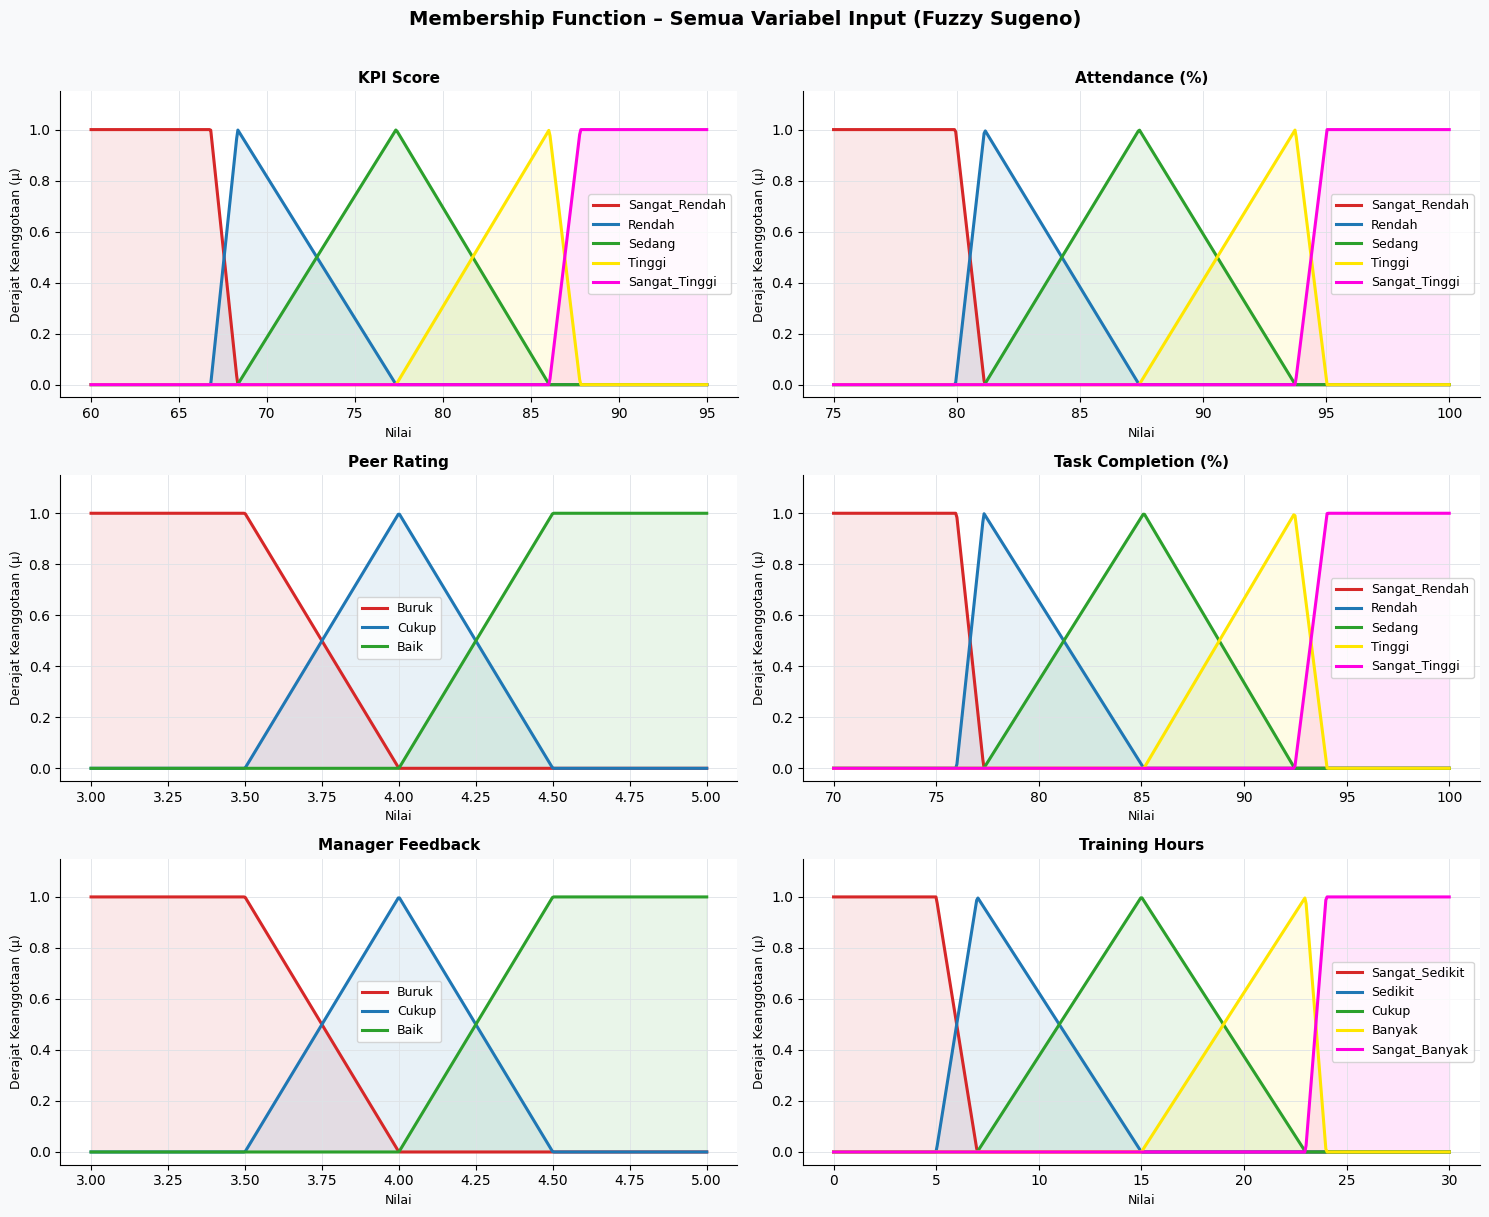

In [94]:
def mf_values(x_arr, params):
    """Hitung derajat keanggotaan untuk array x sesuai panjang params."""
    fn = trapmf if len(params) == 4 else trimf
    return [fn(x, *params) for x in x_arr]

RANGES = {
    'KPI Score': (60, 95), 'Attendance (%)': (75, 100),
    'Peer Rating': (3, 5), 'Task Completion (%)': (70, 100),
    'Manager Feedback': (3, 5), 'Training Hours': (0, 30),
}
LABEL_COLORS = ['#D62728', '#1F77B4', '#2CA02C', "#FFE600", "#FF00E1"]   # merah, biru, hijau

fig, axes = plt.subplots(3, 2, figsize=(15, 12), facecolor='#F8F9FA')
axes = axes.flatten()

for idx, (var, himpunan) in enumerate(MEMBERSHIP.items()):
    ax  = axes[idx]
    ax.set_facecolor('white')
    lo, hi = RANGES[var]
    x  = np.linspace(lo, hi, 500)

    for (nama, params), clr in zip(himpunan.items(), LABEL_COLORS):
        y = mf_values(x, params)
        ax.plot(x, y, color=clr, lw=2.2, label=nama)
        ax.fill_between(x, y, alpha=0.10, color=clr)

    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=9)
    ax.set_ylabel('Derajat Keanggotaan (μ)', fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9)
    ax.grid(True, color='#DEE2E6', lw=0.6)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Membership Function – Semua Variabel Input (Fuzzy Sugeno)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Fuzzifikasi

Fuzzifikasi adalah proses mengubah nilai input *crisp* menjadi **derajat keanggotaan** di setiap himpunan fuzzy yang telah didefinisikan. Hasilnya adalah dictionary berisi nilai μ (mu) untuk setiap himpunan per variabel.

In [95]:
def fuzzify(row: pd.Series) -> dict:
    """
    Fuzzifikasi satu baris data.
    Mengembalikan dict berisi derajat keanggotaan tiap himpunan
    untuk setiap variabel input.
    """
    kpi  = row['KPI Score']
    att  = row['Attendance (%)']
    peer = row['Peer Rating']
    task = row['Task Completion (%)']
    mgr  = row['Manager Feedback']
    trn  = row['Training Hours']

    mf = MEMBERSHIP   # alias pendek

    return {
        'kpi' : {
            'SR': trapmf(kpi,  *mf['KPI Score']['Sangat_Rendah']),
            'R': trimf(kpi,  *mf['KPI Score']['Rendah']),
            'S': trimf (kpi,  *mf['KPI Score']['Sedang']),
            'T': trimf(kpi,  *mf['KPI Score']['Tinggi']),
            'ST': trapmf(kpi,  *mf['KPI Score']['Sangat_Tinggi']),
        },
        'att' : {
            'SR': trapmf(att,  *mf['Attendance (%)']['Sangat_Rendah']),
            'R': trimf(att,  *mf['Attendance (%)']['Rendah']),
            'S': trimf (att,  *mf['Attendance (%)']['Sedang']),
            'T': trimf(att,  *mf['Attendance (%)']['Tinggi']),
            'ST': trapmf(att,  *mf['Attendance (%)']['Sangat_Tinggi']),
        },
        'peer': {
            'R': trapmf(peer, *mf['Peer Rating']['Buruk']),
            'S': trimf (peer, *mf['Peer Rating']['Cukup']),
            'T': trapmf(peer, *mf['Peer Rating']['Baik']),
        },
        'task': {
            'SR': trapmf(task, *mf['Task Completion (%)']['Sangat_Rendah']),
            'R': trimf(task, *mf['Task Completion (%)']['Rendah']),
            'S': trimf (task, *mf['Task Completion (%)']['Sedang']),
            'T': trimf(task, *mf['Task Completion (%)']['Tinggi']),
            'ST': trapmf(task, *mf['Task Completion (%)']['Sangat_Tinggi']),
        },
        'mgr' : {
            'R': trapmf(mgr,  *mf['Manager Feedback']['Buruk']),
            'S': trimf (mgr,  *mf['Manager Feedback']['Cukup']),
            'T': trapmf(mgr,  *mf['Manager Feedback']['Baik']),
        },
        'trn' : {
            'SR': trapmf(trn,  *mf['Training Hours']['Sangat_Sedikit']),
            'R': trimf(trn,  *mf['Training Hours']['Sedikit']),
            'S': trimf (trn,  *mf['Training Hours']['Cukup']),
            'T': trimf(trn,  *mf['Training Hours']['Banyak']),
            'ST': trapmf(trn,  *mf['Training Hours']['Sangat_Banyak']),
        },
    }

In [96]:
# ── Contoh fuzzifikasi pada 1 baris data ──────────────────────────
sample_row = pd.Series({
    'KPI Score': 85, 'Attendance (%)': 90, 'Peer Rating': 4.5,
    'Task Completion (%)': 92, 'Manager Feedback': 4.6, 'Training Hours': 18
})

f_sample = fuzzify(sample_row)

label_map = {
    'kpi':'KPI Score', 'att':'Attendance (%)', 'peer':'Peer Rating',
    'task':'Task Completion (%)', 'mgr':'Manager Feedback', 'trn':'Training Hours'
}
himpunan_map = {
    'kpi' :['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'att' :['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'peer':['Buruk','Cukup','Baik'],
    'task':['Sangat Rendah','Rendah','Sedang','Tinggi', 'Sangat Tinggi'],
    'mgr' :['Buruk','Cukup','Baik'],
    'trn' :['Sangat Sedikit','Sedikit','Cukup','Banyak','Sangat Banyak'],
}

print('=== Hasil Fuzzifikasi Contoh Data ===')
for key, vals in f_sample.items():
    labels = himpunan_map[key]
    print(f'  {label_map[key]:<22} → ', end='')
    for lbl, (k, v) in zip(labels, vals.items()):
        print(f'{lbl}={v:.4f}  ', end='')
    print()

=== Hasil Fuzzifikasi Contoh Data ===
  KPI Score              → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.1206  Tinggi=0.8794  Sangat Tinggi=0.0000  
  Attendance (%)         → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.5915  Tinggi=0.4085  Sangat Tinggi=0.0000  
  Peer Rating            → Buruk=0.0000  Cukup=0.0000  Baik=1.0000  
  Task Completion (%)    → Sangat Rendah=0.0000  Rendah=0.0000  Sedang=0.0639  Tinggi=0.9361  Sangat Tinggi=0.0000  
  Manager Feedback       → Buruk=0.0000  Cukup=0.0000  Baik=1.0000  
  Training Hours         → Sangat Sedikit=0.0000  Sedikit=0.0000  Cukup=0.6250  Banyak=0.3750  Sangat Banyak=0.0000  


---
## 4. Rule Base (Basis Aturan)

Sistem Fuzzy Sugeno menggunakan **24 rule** dengan format:

> **IF** *antecedent_1* **AND** *antecedent_2* **[AND ...]** **THEN** *output = konstanta*

Dalam Sugeno, **output setiap rule adalah konstanta crisp** (Order-0), bukan himpunan fuzzy seperti Mamdani. Konstanta dipilih dari 4 level yang mewakili rentang Performance Score aktual.

**Operator AND** menggunakan fungsi **minimum** (t-norm standar Mamdani/Sugeno):
$$\mu_{rule} = \min(\mu_{A_1}, \mu_{A_2}, \ldots)$$

In [97]:
# Tampilkan daftar rule dalam format teks
RULE_DESCRIPTIONS = [
    # ── TINGGI (z = 93.5) ──────────────────────────────────────────
    'R01: IF KPI Tinggi    AND Attendance Tinggi  AND Task Tinggi    THEN 93.5',
    'R02: IF KPI Tinggi    AND Peer Baik          AND Manager Baik   THEN 93.5',
    'R03: IF Task Tinggi   AND Manager Baik       AND Peer Baik      THEN 93.5',
    'R04: IF KPI Tinggi    AND Attendance Sedang  AND Manager Baik   THEN 93.5',
    'R05: IF KPI Tinggi    AND Training Cukup     AND Task Tinggi    THEN 93.5',
    'R06: IF KPI Tinggi    AND Attendance Tinggi  AND Manager Baik   THEN 93.5',
    # ── SEDANG_ATAS (z = 81.0) ─────────────────────────────────────
    'R07: IF KPI Sedang    AND Attendance Tinggi                     THEN 81.0',
    'R08: IF KPI Tinggi    AND Attendance Sedang                     THEN 81.0',
    'R09: IF Task Sedang   AND Manager Baik                          THEN 81.0',
    'R10: IF Peer Cukup    AND Manager Baik                          THEN 81.0',
    'R11: IF KPI Sedang    AND Task Tinggi                           THEN 81.0',
    'R12: IF Attendance Sedang AND Task Sedang                       THEN 81.0',
    # ── SEDANG_BAWAH (z = 68.5) ────────────────────────────────────
    'R13: IF KPI Sedang    AND Attendance Sedang                     THEN 68.5',
    'R14: IF Peer Cukup    AND Task Sedang                           THEN 68.5',
    'R15: IF Manager Cukup AND Training Cukup                        THEN 68.5',
    'R16: IF Attendance Rendah AND Task Tinggi                       THEN 68.5',
    'R17: IF KPI Rendah    AND Peer Cukup                            THEN 68.5',
    'R18: IF Training Cukup AND Attendance Sedang                    THEN 68.5',
    # ── RENDAH (z = 56.0) ──────────────────────────────────────────
    'R19: IF KPI Rendah    AND Attendance Rendah                     THEN 56.0',
    'R20: IF Task Rendah   AND Manager Buruk                         THEN 56.0',
    'R21: IF Peer Buruk    AND Manager Buruk                         THEN 56.0',
    'R22: IF KPI Rendah    AND Task Rendah                           THEN 56.0',
    'R23: IF Attendance Rendah AND Training Sedikit                  THEN 56.0',
    'R24: IF KPI Rendah    AND Manager Buruk                         THEN 56.0',
]

print(f'Total rules : {len(RULE_DESCRIPTIONS)}\n')
for r in RULE_DESCRIPTIONS:
    print(' ', r)

Total rules : 24

  R01: IF KPI Tinggi    AND Attendance Tinggi  AND Task Tinggi    THEN 93.5
  R02: IF KPI Tinggi    AND Peer Baik          AND Manager Baik   THEN 93.5
  R03: IF Task Tinggi   AND Manager Baik       AND Peer Baik      THEN 93.5
  R04: IF KPI Tinggi    AND Attendance Sedang  AND Manager Baik   THEN 93.5
  R05: IF KPI Tinggi    AND Training Cukup     AND Task Tinggi    THEN 93.5
  R06: IF KPI Tinggi    AND Attendance Tinggi  AND Manager Baik   THEN 93.5
  R07: IF KPI Sedang    AND Attendance Tinggi                     THEN 81.0
  R08: IF KPI Tinggi    AND Attendance Sedang                     THEN 81.0
  R09: IF Task Sedang   AND Manager Baik                          THEN 81.0
  R10: IF Peer Cukup    AND Manager Baik                          THEN 81.0
  R11: IF KPI Sedang    AND Task Tinggi                           THEN 81.0
  R12: IF Attendance Sedang AND Task Sedang                       THEN 81.0
  R13: IF KPI Sedang    AND Attendance Sedang                     THEN

---
## 5. Inferensi Sugeno

Setiap rule dievaluasi menggunakan operator **minimum** pada antecedent-nya. Hasil evaluasi adalah **firing strength (bobot)** setiap rule — seberapa kuat rule tersebut berlaku untuk input yang diberikan.

In [98]:
def evaluate_rules(f: dict) -> list:
    """
    Evaluasi 48 rule fuzzy Sugeno (5 level output).
    Key himpunan:
      SR = Sangat Rendah   R = Rendah   S = Sedang   T = Tinggi   ST = Sangat Tinggi
      (Peer Rating & Manager Feedback tetap 3 level: R=Buruk, S=Cukup, T=Baik)
    Input  : f = hasil fuzzify()
    Output : list of (firing_strength, output_constant)
    """
    rules = [

        # ── SANGAT TINGGI (z = 93.5) ──────────────────────────────
        (min(f['kpi']['ST'], f['att']['ST'], f['task']['ST']),           Z['Sangat_Tinggi']),  # R01
        (min(f['kpi']['ST'], f['mgr']['T'],  f['peer']['T']),            Z['Sangat_Tinggi']),  # R02
        (min(f['kpi']['ST'], f['task']['ST'], f['mgr']['T']),            Z['Sangat_Tinggi']),  # R03
        (min(f['kpi']['ST'], f['att']['ST'], f['mgr']['T']),             Z['Sangat_Tinggi']),  # R04
        (min(f['task']['ST'],f['mgr']['T'],  f['peer']['T']),            Z['Sangat_Tinggi']),  # R05
        (min(f['kpi']['ST'], f['att']['T'],  f['task']['ST']),           Z['Sangat_Tinggi']),  # R06
        (min(f['kpi']['T'],  f['att']['ST'], f['task']['ST']),           Z['Sangat_Tinggi']),  # R07
        (min(f['kpi']['ST'], f['task']['ST'], f['trn']['T']),            Z['Sangat_Tinggi']),  # R08
        (min(f['kpi']['ST'], f['att']['ST'], f['peer']['T']),            Z['Sangat_Tinggi']),  # R09
        (min(f['task']['ST'],f['att']['ST'], f['mgr']['T']),             Z['Sangat_Tinggi']),  # R10

        # ── TINGGI (z = 83.0) ─────────────────────────────────────
        (min(f['kpi']['T'],  f['att']['T'],  f['task']['T']),            Z['Tinggi']),         # R11
        (min(f['kpi']['T'],  f['mgr']['T'],  f['task']['T']),            Z['Tinggi']),         # R12
        (min(f['kpi']['ST'], f['att']['S'],  f['task']['T']),            Z['Tinggi']),         # R13
        (min(f['kpi']['T'],  f['att']['ST'], f['task']['S']),            Z['Tinggi']),         # R14
        (min(f['task']['T'], f['mgr']['T'],  f['att']['S']),             Z['Tinggi']),         # R15
        (min(f['kpi']['T'],  f['peer']['T'], f['att']['T']),             Z['Tinggi']),         # R16
        (min(f['kpi']['T'],  f['task']['T'], f['trn']['T']),             Z['Tinggi']),         # R17
        (min(f['kpi']['ST'], f['mgr']['S'],  f['task']['T']),            Z['Tinggi']),         # R18
        (min(f['att']['T'],  f['task']['ST'], f['mgr']['S']),            Z['Tinggi']),         # R19
        (min(f['kpi']['T'],  f['att']['T'],  f['trn']['ST']),            Z['Tinggi']),         # R20

        # ── SEDANG (z = 75.0) ─────────────────────────────────────
        (min(f['kpi']['S'],  f['att']['S'],  f['task']['S']),            Z['Sedang']),         # R21
        (min(f['kpi']['T'],  f['att']['R'],  f['task']['S']),            Z['Sedang']),         # R22
        (min(f['kpi']['S'],  f['att']['T'],  f['task']['R']),            Z['Sedang']),         # R23
        (min(f['kpi']['R'],  f['att']['ST'], f['task']['T']),            Z['Sedang']),         # R24
        (min(f['kpi']['S'],  f['mgr']['S'],  f['task']['T']),            Z['Sedang']),         # R25
        (min(f['kpi']['S'],  f['att']['S'],  f['mgr']['T']),             Z['Sedang']),         # R26
        (min(f['kpi']['T'],  f['att']['S'],  f['task']['R']),            Z['Sedang']),         # R27
        (min(f['task']['S'], f['att']['S'],  f['peer']['S']),            Z['Sedang']),         # R28
        (min(f['kpi']['S'],  f['task']['S'], f['trn']['S']),             Z['Sedang']),         # R29
        (min(f['kpi']['R'],  f['mgr']['T'],  f['task']['ST']),           Z['Sedang']),         # R30

        # ── RENDAH (z = 68.5) ─────────────────────────────────────
        (min(f['kpi']['R'],  f['att']['R'],  f['task']['R']),            Z['Rendah']),         # R31
        (min(f['kpi']['SR'], f['att']['S'],  f['task']['S']),            Z['Rendah']),         # R32
        (min(f['kpi']['R'],  f['mgr']['S'],  f['task']['R']),            Z['Rendah']),         # R33
        (min(f['kpi']['S'],  f['att']['SR'], f['task']['R']),            Z['Rendah']),         # R34
        (min(f['kpi']['R'],  f['task']['R'], f['trn']['R']),             Z['Rendah']),         # R35
        (min(f['kpi']['R'],  f['att']['R'],  f['peer']['S']),            Z['Rendah']),         # R36
        (min(f['task']['R'], f['mgr']['S'],  f['att']['R']),             Z['Rendah']),         # R37
        (min(f['kpi']['S'],  f['att']['R'],  f['task']['SR']),           Z['Rendah']),         # R38
        (min(f['kpi']['R'],  f['mgr']['R'],  f['att']['S']),             Z['Rendah']),         # R39
        (min(f['task']['SR'],f['att']['R'],  f['trn']['S']),             Z['Rendah']),         # R40

        # ── SANGAT RENDAH (z = 56.0) ──────────────────────────────
        (min(f['kpi']['SR'], f['att']['SR'], f['task']['SR']),           Z['Sangat_Rendah']),  # R41
        (min(f['kpi']['SR'], f['mgr']['R'],  f['task']['R']),            Z['Sangat_Rendah']),  # R42
        (min(f['kpi']['SR'], f['att']['R'],  f['task']['SR']),           Z['Sangat_Rendah']),  # R43
        (min(f['kpi']['R'],  f['att']['SR'], f['task']['SR']),           Z['Sangat_Rendah']),  # R44
        (min(f['kpi']['SR'], f['task']['SR'], f['trn']['SR']),           Z['Sangat_Rendah']),  # R45
        (min(f['kpi']['SR'], f['att']['SR'], f['mgr']['R']),             Z['Sangat_Rendah']),  # R46
        (min(f['task']['SR'],f['mgr']['R'],  f['peer']['R']),            Z['Sangat_Rendah']),  # R47
        (min(f['kpi']['SR'], f['att']['SR'], f['peer']['R']),            Z['Sangat_Rendah']),  # R48

    ]
    return rules

In [99]:
# Contoh inferensi pada data sampel
rules_sample = evaluate_rules(f_sample)

print('=== Firing Strength Tiap Rule (Contoh Data) ===')
print(f"{'Rule':<6} {'Firing Strength':>16} {'Output Z':>10}")
print('-' * 36)
for i, (w, z) in enumerate(rules_sample, 1):
    active = ' ← aktif' if w > 0 else ''
    print(f"R{i:02d}    {w:>16.4f} {z:>10.1f}{active}")

=== Firing Strength Tiap Rule (Contoh Data) ===
Rule    Firing Strength   Output Z
------------------------------------
R01              0.0000       93.5
R02              0.0000       93.5
R03              0.0000       93.5
R04              0.0000       93.5
R05              0.0000       93.5
R06              0.0000       93.5
R07              0.0000       93.5
R08              0.0000       93.5
R09              0.0000       93.5
R10              0.0000       93.5
R11              0.4085       83.0 ← aktif
R12              0.8794       83.0 ← aktif
R13              0.0000       83.0
R14              0.0000       83.0
R15              0.5915       83.0 ← aktif
R16              0.4085       83.0 ← aktif
R17              0.3750       83.0 ← aktif
R18              0.0000       83.0
R19              0.0000       83.0
R20              0.0000       83.0
R21              0.0639       75.0 ← aktif
R22              0.0000       75.0
R23              0.0000       75.0
R24              0.0000    

---
## 6. Defuzzifikasi – Weighted Average

Pada Sugeno, defuzzifikasi menggunakan metode **Weighted Average (WA)**:

$$\text{Output} = \frac{\sum_{i=1}^{n} w_i \cdot z_i}{\sum_{i=1}^{n} w_i}$$

Di mana:
- $w_i$ = firing strength rule ke-$i$
- $z_i$ = konstanta output rule ke-$i$

Ini berbeda dengan Mamdani yang menggunakan centroid pada himpunan fuzzy hasil agregasi.

In [100]:
def defuzzify_wa(rules: list) -> float:
    """
    Defuzzifikasi Weighted Average (Sugeno).
    Jika semua firing strength = 0, kembalikan nilai tengah domain (fallback).
    """
    total_weight = sum(w for w, _ in rules)
    if total_weight == 0:
        return 68.5   # fallback = titik tengah domain output
    return sum(w * z for w, z in rules) / total_weight


def predict_one(row: pd.Series) -> float:
    """Pipeline lengkap: fuzzifikasi → inferensi → defuzzifikasi untuk 1 baris."""
    f     = fuzzify(row)
    rules = evaluate_rules(f)
    return defuzzify_wa(rules)

In [101]:
# Contoh defuzzifikasi pada data sampel
result_sample = defuzzify_wa(rules_sample)
total_w  = sum(w for w, _ in rules_sample)
weighted = sum(w * z for w, z in rules_sample)

print('=== Proses Defuzzifikasi Weighted Average ===')
print(f'  Σ(w × z) = {weighted:.4f}')
print(f'  Σ(w)     = {total_w:.4f}')
print(f'  Output   = {weighted:.4f} / {total_w:.4f} = {result_sample:.4f}')
print()

if result_sample >= 87:
    kategori = 'Tinggi'
elif result_sample >= 75:
    kategori = 'Sedang Atas'
elif result_sample >= 62:
    kategori = 'Sedang Bawah'
else:
    kategori = 'Rendah'

print(f'  Predicted Performance Score = {result_sample:.2f}  →  Kategori: {kategori}')

=== Proses Defuzzifikasi Weighted Average ===
  Σ(w × z) = 239.6594
  Σ(w)     = 2.9114
  Output   = 239.6594 / 2.9114 = 82.3173

  Predicted Performance Score = 82.32  →  Kategori: Sedang Atas


---
## 7. Prediksi pada Seluruh Dataset

Pipeline fuzzy Sugeno diterapkan pada semua 5.000 baris data untuk menghasilkan prediksi `Performance Score` yang kemudian dibandingkan dengan nilai aktual.

In [102]:
print('Menjalankan prediksi fuzzy Sugeno pada seluruh dataset...')

df['Predicted_Sugeno'] = df.apply(predict_one, axis=1)

# Kategori berdasarkan Q1/Median/Q3 Performance Score
def to_kategori(score):
    if   score >= 87: return 'Tinggi'
    elif score >= 75: return 'Sedang Atas'
    elif score >= 62: return 'Sedang Bawah'
    else:             return 'Rendah'

df['Kategori_Aktual']    = df[OUTPUT_COL].apply(to_kategori)
df['Kategori_Prediksi']  = df['Predicted_Sugeno'].apply(to_kategori)

print(f'Selesai. Total baris diproses: {len(df):,}')
print()
print('=== Sample 10 Baris Hasil Prediksi ===')
print(df[[OUTPUT_COL, 'Predicted_Sugeno', 'Kategori_Aktual', 'Kategori_Prediksi']].head(10).to_string())

Menjalankan prediksi fuzzy Sugeno pada seluruh dataset...
Selesai. Total baris diproses: 5,000

=== Sample 10 Baris Hasil Prediksi ===
   Performance Score  Predicted_Sugeno Kategori_Aktual Kategori_Prediksi
0                 61         93.500000          Rendah            Tinggi
1                 91         68.500000          Tinggi      Sedang Bawah
2                100         56.000000          Tinggi            Rendah
3                100         68.500000          Tinggi      Sedang Bawah
4                 80         75.000000     Sedang Atas       Sedang Atas
5                 53         70.627027          Rendah      Sedang Bawah
6                 59         68.500000          Rendah      Sedang Bawah
7                 98         93.500000          Tinggi            Tinggi
8                 83         68.500000     Sedang Atas      Sedang Bawah
9                 70         74.477350    Sedang Bawah      Sedang Bawah


---
## 8. Evaluasi Performa – MAE, MSE, RMSE

Evaluasi dilakukan menggunakan tiga metrik regresi standar:

$$\text{MAE}  = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$\text{MSE}  = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

$$\text{RMSE} = \sqrt{\text{MSE}}$$

In [103]:
actuals   = df[OUTPUT_COL].values
predicted = df['Predicted_Sugeno'].values
errors    = actuals - predicted

MAE  = np.mean(np.abs(errors))
MSE  = np.mean(errors ** 2)
RMSE = np.sqrt(MSE)

print('=' * 40)
print('   EVALUASI FUZZY SUGENO')
print('=' * 40)
print(f'   MAE  = {MAE:.4f}')
print(f'   MSE  = {MSE:.4f}')
print(f'   RMSE = {RMSE:.4f}')
print('=' * 40)
print(f'   Range aktual   : [{actuals.min():.1f}, {actuals.max():.1f}]')
print(f'   Range prediksi : [{predicted.min():.2f}, {predicted.max():.2f}]')
print(f'   Rata-rata error: {np.mean(errors):.4f}')

   EVALUASI FUZZY SUGENO
   MAE  = 14.8389
   MSE  = 326.1706
   RMSE = 18.0602
   Range aktual   : [50.0, 100.0]
   Range prediksi : [56.00, 93.50]
   Rata-rata error: 0.9615


---
## 9. Visualisasi Hasil

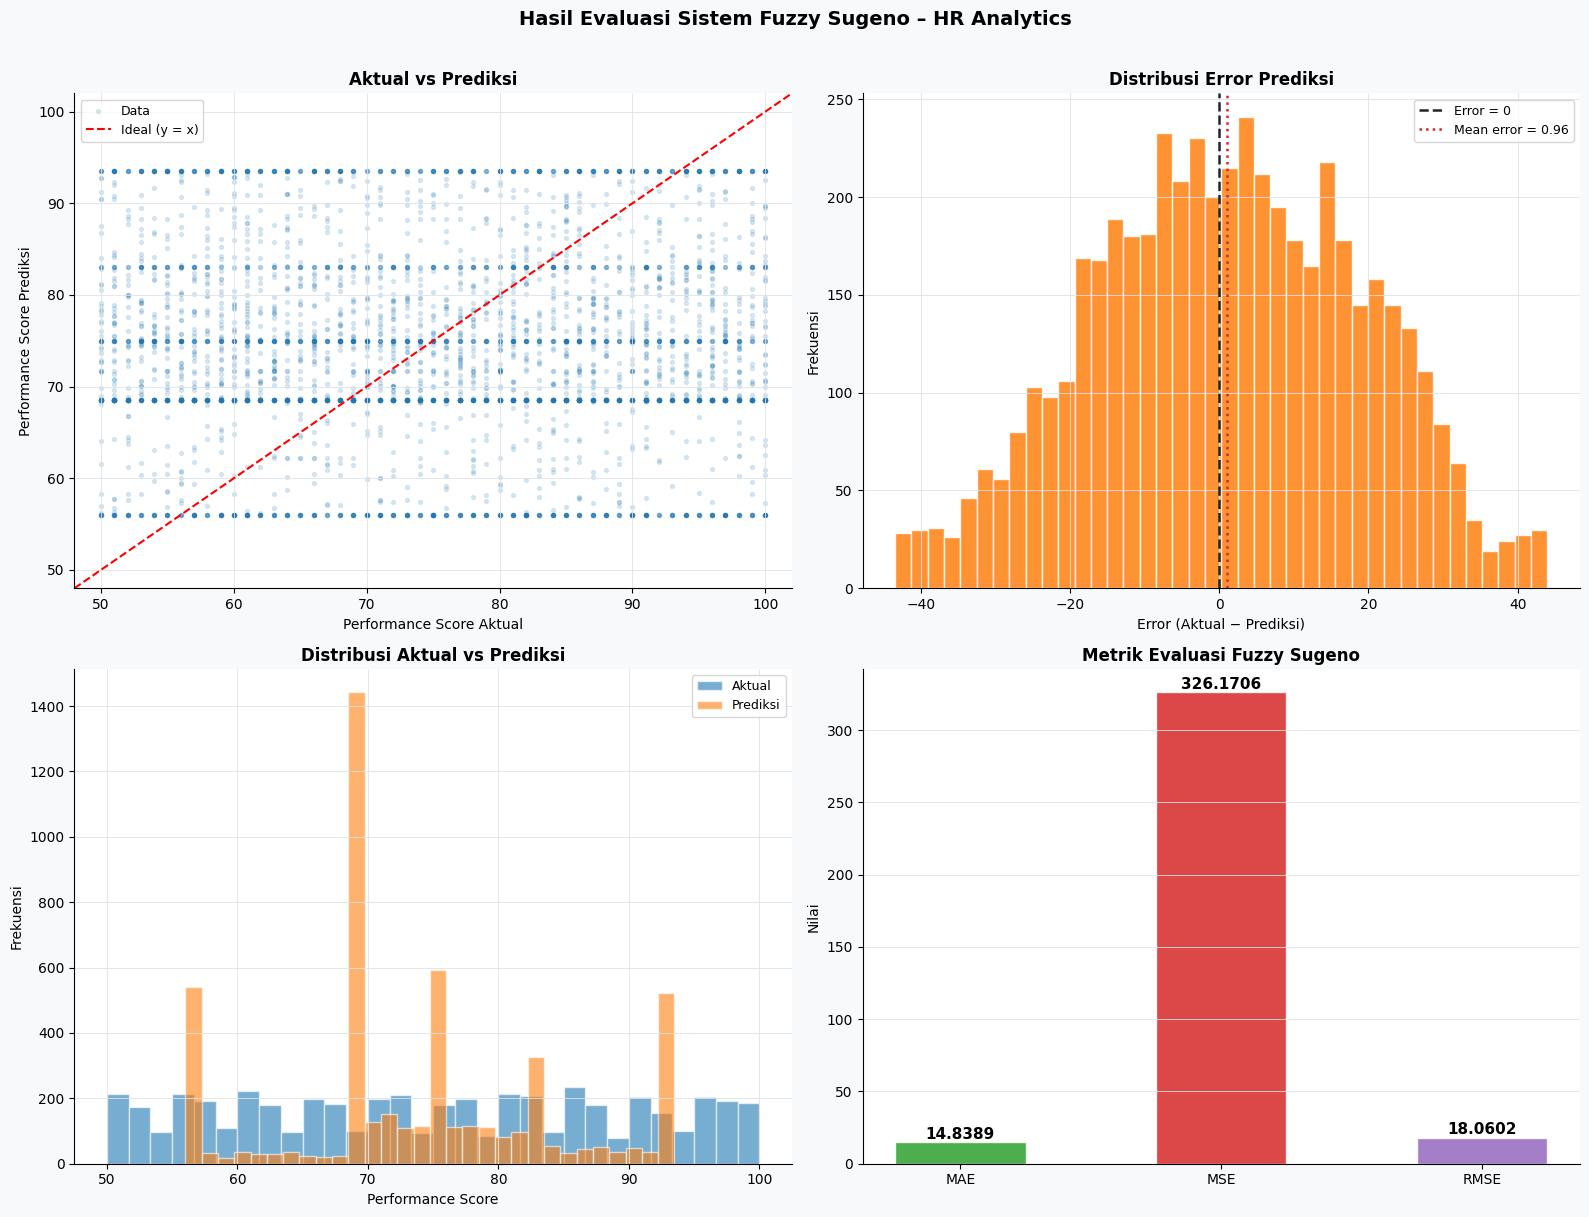

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#F8F9FA')

# ── 9.1 Scatter: Aktual vs Prediksi ───────────────────────────────
ax1 = axes[0, 0]
ax1.set_facecolor('white')
ax1.scatter(actuals, predicted, alpha=0.15, s=8, color='#1F77B4', label='Data')
lims = [min(actuals.min(), predicted.min()) - 2,
        max(actuals.max(), predicted.max()) + 2]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Ideal (y = x)')
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel('Performance Score Aktual', fontsize=10)
ax1.set_ylabel('Performance Score Prediksi', fontsize=10)
ax1.set_title('Aktual vs Prediksi', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, color='#DEE2E6', lw=0.6)
ax1.spines[['top', 'right']].set_visible(False)

# ── 9.2 Histogram Error ───────────────────────────────────────────
ax2 = axes[0, 1]
ax2.set_facecolor('white')
ax2.hist(errors, bins=40, color='#FF7F0E', edgecolor='white', alpha=0.85)
ax2.axvline(0,           color='#212529', lw=1.8, ls='--', label='Error = 0')
ax2.axvline(np.mean(errors), color='#D62728', lw=1.8, ls=':',
            label=f'Mean error = {np.mean(errors):.2f}')
ax2.set_xlabel('Error (Aktual − Prediksi)', fontsize=10)
ax2.set_ylabel('Frekuensi', fontsize=10)
ax2.set_title('Distribusi Error Prediksi', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, color='#DEE2E6', lw=0.6)
ax2.spines[['top', 'right']].set_visible(False)

# ── 9.3 Distribusi Prediksi vs Aktual ─────────────────────────────
ax3 = axes[1, 0]
ax3.set_facecolor('white')
ax3.hist(actuals,   bins=30, alpha=0.6, color='#1F77B4', label='Aktual',   edgecolor='white')
ax3.hist(predicted, bins=30, alpha=0.6, color='#FF7F0E', label='Prediksi', edgecolor='white')
ax3.set_xlabel('Performance Score', fontsize=10)
ax3.set_ylabel('Frekuensi', fontsize=10)
ax3.set_title('Distribusi Aktual vs Prediksi', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, color='#DEE2E6', lw=0.6)
ax3.spines[['top', 'right']].set_visible(False)

# ── 9.4 Bar Metrik Evaluasi ───────────────────────────────────────
ax4 = axes[1, 1]
ax4.set_facecolor('white')
metrik = ['MAE', 'MSE', 'RMSE']
nilai  = [MAE, MSE, RMSE]
colors_bar = ['#2CA02C', '#D62728', '#9467BD']
bars = ax4.bar(metrik, nilai, color=colors_bar, edgecolor='white', alpha=0.85, width=0.5)
for bar, val in zip(bars, nilai):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.set_title('Metrik Evaluasi Fuzzy Sugeno', fontsize=12, fontweight='bold')
ax4.set_ylabel('Nilai', fontsize=10)
ax4.grid(True, axis='y', color='#DEE2E6', lw=0.6)
ax4.spines[['top', 'right']].set_visible(False)

fig.suptitle('Hasil Evaluasi Sistem Fuzzy Sugeno – HR Analytics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Ringkasan Sistem Fuzzy Sugeno

Cell ini mencetak ringkasan lengkap sistem yang telah dibangun — berguna sebagai acuan saat penggabungan notebook dan penyusunan laporan.

In [105]:
print('=' * 55)
print('        RINGKASAN SISTEM FUZZY SUGENO')
print('=' * 55)
print(f'  Metode           : Fuzzy Sugeno (TSK Order-0)')
print(f'  Total data       : {len(df):,} baris')
print(f'  Variabel input   : {len(INPUT_COLS)} variabel')
for c in INPUT_COLS:
    print(f'                     - {c}')
print(f'  Variabel output  : {OUTPUT_COL}')
print(f'  Jumlah himpunan  : 3 per variabel input')
print(f'  Fungsi keangg.   : Triangular & Trapezoidal')
print(f'  Jumlah rule      : 24 rule')
print(f'  Operator AND     : Minimum (t-norm)')
print(f'  Output per rule  : Konstanta crisp (Order-0)')
print(f'  Output konstanta : {Z}')
print(f'  Defuzzifikasi    : Weighted Average')
print('-' * 55)
print(f'  MAE              : {MAE:.4f}')
print(f'  MSE              : {MSE:.4f}')
print(f'  RMSE             : {RMSE:.4f}')
print('=' * 55)

        RINGKASAN SISTEM FUZZY SUGENO
  Metode           : Fuzzy Sugeno (TSK Order-0)
  Total data       : 5,000 baris
  Variabel input   : 6 variabel
                     - KPI Score
                     - Attendance (%)
                     - Peer Rating
                     - Task Completion (%)
                     - Manager Feedback
                     - Training Hours
  Variabel output  : Performance Score
  Jumlah himpunan  : 3 per variabel input
  Fungsi keangg.   : Triangular & Trapezoidal
  Jumlah rule      : 24 rule
  Operator AND     : Minimum (t-norm)
  Output per rule  : Konstanta crisp (Order-0)
  Output konstanta : {'Sangat_Rendah': 56.0, 'Rendah': 68.5, 'Sedang': 75.0, 'Tinggi': 83.0, 'Sangat_Tinggi': 93.5}
  Defuzzifikasi    : Weighted Average
-------------------------------------------------------
  MAE              : 14.8389
  MSE              : 326.1706
  RMSE             : 18.0602


In [106]:
low_weight = []
for _, row in df.iterrows():
    f = fuzzify(row)
    rules = evaluate_rules(f)
    total_w = sum(w for w, _ in rules)
    low_weight.append(total_w)

df['total_firing'] = low_weight
print(df['total_firing'].describe())
print("Baris dengan total firing < 0.1:", (df['total_firing'] < 0.1).sum())

count    5000.000000
mean        0.750978
std         0.749552
min         0.000000
25%         0.147699
50%         0.600000
75%         1.062904
max         7.000000
Name: total_firing, dtype: float64
Baris dengan total firing < 0.1: 1154
